# Paper 2 — Goal 3 Stage B
## Signal-only perturbation calibration — execution and dose freeze

**Version:** v1.1.0

This notebook executes the outcome-blind Goal 3 dose-calibration experiment after the Stage-B preparation gate has passed.

### Scientific purpose

For each prespecified acquisition transformation, determine physical **low / medium / high** settings using only signal-derived Q responses. Clinical labels, bulbar scores, Goal 2 predictions, prediction error, and Goal 3 clinical-model responses are not loaded anywhere in this notebook.

The target design is:

- baseline + low + medium + high;
- approximately 0.5 / 1.0 / 2.0 natural IQR target-Q movement where feasible;
- strictly ordered median target-Q response;
- target-Q direction verified across pilot sources;
- all off-target Core-Q changes documented;
- QDIST uses the validated Paper 1 hard-clipping burden grid rather than natural Q quantiles.

### Important v1.1 implementation amendment

The earlier preparation notebook froze the *candidate physical grid and selection rule* but had not yet generated Q-response data. Before executing any pilot response, the transformation implementation was audited against the pinned Paper 1 repository.

This execution version therefore uses:

- the exact Paper 1 QGAIN gain helpers;
- the exact Paper 1 QCHAN Butterworth low-pass helper;
- the exact Paper 1 QDIST matched hard-clipping challenge helper;
- the exact synthetic-RIR formula used in the Paper 1 QREV analytical preflight;
- the exact reviewed Paper 1 Q extractors and canonical Silero segmentation implementation.

No clinical information had been unblinded before this amendment. The physical candidate grids remain the Stage-B preparation grids.

### Run order

1. Run once with `RUN_MODE = "SMOKE"`.
2. Inspect the final smoke gates.
3. If smoke passes, change **one line only** to `RUN_MODE = "FINAL"`.
4. Restart kernel and run all cells.
5. FINAL freezes `goal3_perturbation_manifest.csv` only if every signal-only calibration gate passes.

In [1]:
from __future__ import annotations

import hashlib
import importlib
import inspect
import itertools
import json
import math
import os
import platform
import re
import shutil
import subprocess
import sys
import time
from dataclasses import replace
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy import signal

# ============================================================
# USER CONTROL — change only this line after SMOKE passes
# ============================================================

RUN_MODE = "FINAL"   # "SMOKE" or "FINAL"

# ============================================================
# FROZEN CONSTANTS
# ============================================================

ENGINE_VERSION = "goal3-stageB-signal-only-v1.1.0"
PAPER1_COMMIT = "cb31fb6886df1b2b2fedba4ffbbf8624bd56d7e8"
BASE_SEED = 20260825

EXPECTED = {
    "retained_recordings": 519,
    "participants": 224,
    "pilot_sources": 24,
    "outer_folds": 5,
}

TARGET_IQR = {
    "low": 0.5,
    "medium": 1.0,
    "high": 2.0,
}

# Prespecified engineering acceptance gates.
# These are frozen before candidate-response inspection.
MIN_SELECTED_FINITE_SOURCES_FINAL = 12
MIN_EXPECTED_DIRECTION_FRACTION_FINAL = 0.70
MIN_HIGH_DOSE_MEDIAN_TARGET_IQR = 1.00

# Paper 1 validated QDIST challenge burdens.
QDIST_FIXED_DOSES = {
    "low": 0.001,
    "medium": 0.003,
    "high": 0.010,
}

QDIST_GEOMETRY = "symmetric"

if RUN_MODE not in {"SMOKE", "FINAL"}:
    raise ValueError("RUN_MODE must be 'SMOKE' or 'FINAL'.")

print("RUN MODE:", RUN_MODE)
print("Engine:", ENGINE_VERSION)
print("Paper 1 commit:", PAPER1_COMMIT)

RUN MODE: FINAL
Engine: goal3-stageB-signal-only-v1.1.0
Paper 1 commit: cb31fb6886df1b2b2fedba4ffbbf8624bd56d7e8


## 1. Project discovery, output isolation, and atomic I/O

In [2]:
def find_project_root() -> Path:
    override = os.environ.get("PAPER2_ROOT", "").strip()
    if override:
        root = Path(override).expanduser().resolve()
        if (root / "data" / "processed" / "recording_table_phase0.csv").exists():
            return root
        raise FileNotFoundError(f"Invalid PAPER2_ROOT: {root}")

    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (
            (candidate / "data" / "processed" / "recording_table_phase0.csv").exists()
            and (candidate / "outputs" / "goal3").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate Paper 2 root. Run this notebook from the repository."
    )

ROOT = find_project_root()

STAGE_A_CANDIDATES = [
    ROOT / "outputs" / "goal3" / "stageA_v1_1",
    ROOT / "outputs" / "goal3" / "stageA_v1_0",
]

STAGE_A = next(
    (
        path
        for path in STAGE_A_CANDIDATES
        if (path / "SUCCESS_STAGE_A.json").exists()
    ),
    None,
)

if STAGE_A is None:
    raise FileNotFoundError("No successful Goal 3 Stage-A output directory found.")

PREP = ROOT / "outputs" / "goal3" / "stageB_signal_only_calibration_v1_0"

if not (PREP / "stageB_readiness.json").exists():
    raise FileNotFoundError(
        "Stage-B preparation output is missing. Run notebook 31 first."
    )

OUT = (
    ROOT
    / "outputs"
    / "goal3"
    / "stageB_signal_only_calibration_v1_1"
    / RUN_MODE.lower()
)

TABLES = OUT / "tables"
AUDIT = OUT / "audit"
FIGURES = OUT / "figures"
CHECKPOINTS = OUT / "checkpoints"
CACHE = OUT / "cache"

for directory in [OUT, TABLES, AUDIT, FIGURES, CHECKPOINTS, CACHE]:
    directory.mkdir(parents=True, exist_ok=True)

MANIFESTS = ROOT / "data" / "manifests"
PROCESSED = ROOT / "data" / "processed"

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def sha256_file(path: str | Path, chunk_size=1024 * 1024) -> str:
    h = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

def stable_hash(*parts) -> str:
    payload = "|".join(str(part) for part in parts)
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()

def stable_seed(*parts) -> int:
    return (
        BASE_SEED
        + int(stable_hash(*parts)[:8], 16)
    ) % (2**32 - 1)

def json_safe(value):
    if value is pd.NA:
        return None
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, pd.Timestamp):
        return None if pd.isna(value) else value.isoformat()
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        return [json_safe(v) for v in value]
    return value

def atomic_json(payload: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_name(f".{path.name}.tmp")
    temp.write_text(
        json.dumps(json_safe(payload), indent=2, sort_keys=True),
        encoding="utf-8",
    )
    os.replace(temp, path)

def atomic_csv(frame: pd.DataFrame, path: Path, *, allow_empty=False):
    if not allow_empty and frame.empty:
        raise ValueError(f"Refusing to write empty table: {path}")
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_name(f".{path.name}.tmp")
    frame.to_csv(temp, index=False)
    if temp.stat().st_size == 0:
        raise IOError(f"Temporary CSV is empty: {temp}")
    os.replace(temp, path)

def read_csv_checked(path: Path, required=None):
    if not path.exists():
        raise FileNotFoundError(path)
    if path.stat().st_size == 0:
        raise RuntimeError(f"Empty CSV: {path}")
    frame = pd.read_csv(path, low_memory=False)
    if required:
        missing = set(required) - set(frame.columns)
        if missing:
            raise KeyError(f"{path.name}: missing columns {sorted(missing)}")
    return frame

def safe_slug(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_")

print("Paper 2 root:", ROOT)
print("Stage A:", STAGE_A)
print("Output:", OUT)

Paper 2 root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code
Stage A: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\stageA_v1_0
Output: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\stageB_signal_only_calibration_v1_1\final


## 2. Outcome-blinding and frozen-input gates

In [3]:
STAGE_A_TABLES = STAGE_A / "tables"

stage_a_success = json.loads(
    (STAGE_A / "SUCCESS_STAGE_A.json").read_text(encoding="utf-8")
)

if stage_a_success.get("status") != "PASS":
    raise RuntimeError("Stage A does not have PASS status.")

prep_readiness = json.loads(
    (PREP / "stageB_readiness.json").read_text(encoding="utf-8")
)

if not bool(prep_readiness.get("candidate_grid_frozen", False)):
    raise RuntimeError("Stage-B candidate grid was not frozen by the prep notebook.")

if not bool(prep_readiness.get("dose_selection_rule_frozen", False)):
    raise RuntimeError("Stage-B dose-selection rule was not frozen.")

if bool(prep_readiness.get("clinical_outcomes_loaded", True)):
    raise RuntimeError("Prep manifest indicates clinical outcomes were loaded.")

if bool(prep_readiness.get("clinical_predictions_loaded", True)):
    raise RuntimeError("Prep manifest indicates clinical predictions were loaded.")

pilot = read_csv_checked(
    STAGE_A_TABLES / "goal3_signal_only_dose_pilot.csv",
    required=["participant_id", "logical_recording_id", "pilot_rank"],
)

crossfit = read_csv_checked(
    STAGE_A_TABLES / "goal3_fixed_fivefold_crossfit.csv",
    required=["participant_id", "outer_fold"],
)

natural_iqr = read_csv_checked(
    STAGE_A_TABLES / "goal3_natural_q_iqr_targets.csv",
    required=["q_feature", "q_family", "natural_iqr_raw"],
)

design = read_csv_checked(
    STAGE_A_TABLES / "goal3_perturbation_design_skeleton.csv",
    required=[
        "family",
        "transform",
        "primary_target_q",
        "expected_primary_direction",
    ],
)

candidate_contract = read_csv_checked(
    PREP / "tables" / "goal3_candidate_grid_contract.csv",
    required=[
        "family",
        "transform",
        "candidate_value",
        "candidate_unit",
        "exemplar",
    ],
)

media_audit = read_csv_checked(
    PREP / "audit" / "pilot_media_hash_audit.csv",
    required=[
        "participant_id",
        "logical_recording_id",
        "resolved_media_path",
        "observed_sha256",
        "sha256_matches",
    ],
)

PROHIBITED_COLUMNS = {
    "diagnosis",
    "Diagnosis",
    "y_dx",
    "bulbar_score",
    "ALSFRS",
    "assessment_date",
    "age_at_recording_years",
    "sex",
    "prediction",
    "loss",
    "absolute_error",
    "brier",
}

for name, frame in [
    ("pilot", pilot),
    ("crossfit", crossfit),
    ("natural_iqr", natural_iqr),
    ("design", design),
    ("candidate_contract", candidate_contract),
    ("media_audit", media_audit),
]:
    leaked = PROHIBITED_COLUMNS & set(frame.columns)
    if leaked:
        raise RuntimeError(
            f"{name} contains prohibited clinical fields: {sorted(leaked)}"
        )

pilot["participant_id"] = pilot["participant_id"].astype(str)
pilot["logical_recording_id"] = pilot["logical_recording_id"].astype(str)
crossfit["participant_id"] = crossfit["participant_id"].astype(str)

if len(pilot) != EXPECTED["pilot_sources"]:
    raise RuntimeError(
        f"Expected 24 pilot sources, found {len(pilot)}."
    )

if crossfit["participant_id"].nunique() != EXPECTED["participants"]:
    raise RuntimeError("Fixed Goal 3 cross-fit does not contain 224 participants.")

if crossfit["outer_fold"].nunique() != EXPECTED["outer_folds"]:
    raise RuntimeError("Fixed Goal 3 cross-fit does not contain five folds.")

pilot = pilot.merge(
    crossfit,
    on="participant_id",
    how="left",
    validate="one_to_one",
)

if pilot["outer_fold"].isna().any():
    raise RuntimeError("Pilot contains participant without fixed outer fold.")

media_audit["participant_id"] = media_audit["participant_id"].astype(str)
media_audit["logical_recording_id"] = media_audit["logical_recording_id"].astype(str)

pilot = pilot.merge(
    media_audit[
        [
            "participant_id",
            "logical_recording_id",
            "resolved_media_path",
            "observed_sha256",
            "sha256_matches",
        ]
    ],
    on=["participant_id", "logical_recording_id"],
    how="left",
    validate="one_to_one",
)

if pilot["resolved_media_path"].isna().any():
    raise RuntimeError("Pilot media path alignment failed.")

if not pilot["sha256_matches"].fillna(False).astype(bool).all():
    raise RuntimeError("Pilot media hash audit did not pass.")

print("OUTCOME-BLIND INPUT GATE: PASS")
print("Pilot sources:", len(pilot))
display(
    pilot[["pilot_rank", "participant_id", "logical_recording_id", "outer_fold"]]
    .sort_values("pilot_rank")
    .head()
)

OUTCOME-BLIND INPUT GATE: PASS
Pilot sources: 24


,pilot_rank,participant_id,logical_recording_id,outer_fold
0,1,CAPT0000114,CAPT0000114_272_1_20240806_240_PSG_BAMBOO,3
1,2,CAPT0000099,CAPT0000099_272_1_20240523_240_PSG_BAMBOO,4
2,3,CNEC012,CNEC012_1045_1_20241012_240_PSG_BAMBOO,5
3,4,CAPT0000170,CAPT0000170_272_1_20250527_240_PSG_BAMBOO,3
4,5,TIBD118,TIBD118_1003_1_20250205_240_PSG_BAMBOO,4


## 3. Pin the exact Paper 1 code and dependencies

The reviewed Q measurement implementations are imported from the exact Paper 1 commit.

No Q estimator is reimplemented in Paper 2.

In [4]:
def git_call(args, cwd=None):
    result = subprocess.run(
        ["git", *args],
        cwd=cwd,
        capture_output=True,
        text=True,
        check=False,
    )
    if result.returncode != 0:
        raise RuntimeError(
            f"git {' '.join(args)} failed:\n{result.stderr}"
        )
    return result.stdout.strip()

repo_candidates = [
    ROOT / "vendor" / "quality_framework_features",
    ROOT.parent / "quality_framework_features",
    Path.home() / "Desktop" / "quality_framework_features",
]

PAPER1_REPO = next(
    (
        path.resolve()
        for path in repo_candidates
        if (path / ".git").exists()
    ),
    None,
)

if PAPER1_REPO is None:
    PAPER1_REPO = (
        ROOT / "vendor" / "quality_framework_features"
    ).resolve()
    PAPER1_REPO.parent.mkdir(parents=True, exist_ok=True)
    git_call(
        [
            "clone",
            "https://github.com/nevena-m3/quality_framework_features.git",
            str(PAPER1_REPO),
        ]
    )

commit = git_call(["rev-parse", "HEAD"], cwd=PAPER1_REPO)

if commit != PAPER1_COMMIT:
    status = git_call(["status", "--porcelain"], cwd=PAPER1_REPO)
    if status:
        raise RuntimeError(
            "Paper 1 checkout is not pinned and has uncommitted changes. "
            "Use a clean vendor checkout."
        )
    git_call(["fetch", "--all", "--tags"], cwd=PAPER1_REPO)
    git_call(["checkout", "--detach", PAPER1_COMMIT], cwd=PAPER1_REPO)

commit = git_call(["rev-parse", "HEAD"], cwd=PAPER1_REPO)

if commit != PAPER1_COMMIT:
    raise RuntimeError("Failed to pin the exact Paper 1 commit.")

SRC = PAPER1_REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

dependency_rows = []

for package in ["numpy", "pandas", "scipy", "silero_vad", "torch", "gammatone"]:
    try:
        module = importlib.import_module(package)
        dependency_rows.append({
            "dependency": package,
            "available": True,
            "version": str(getattr(module, "__version__", "installed")),
            "error": "",
        })
    except Exception as exc:
        dependency_rows.append({
            "dependency": package,
            "available": False,
            "version": "",
            "error": repr(exc),
        })

for executable in ["ffmpeg", "ffprobe"]:
    resolved = shutil.which(executable)
    dependency_rows.append({
        "dependency": executable,
        "available": bool(resolved),
        "version": resolved or "",
        "error": "",
    })

dependency_audit = pd.DataFrame(dependency_rows)
atomic_csv(dependency_audit, AUDIT / "dependency_audit.csv")
display(dependency_audit)

missing = dependency_audit.loc[
    ~dependency_audit["available"],
    "dependency",
].tolist()

if missing:
    raise RuntimeError(
        "Missing required pinned-runtime dependencies: "
        + ", ".join(missing)
    )

print("PINNED PAPER 1 / DEPENDENCY GATE: PASS")
print("Paper 1 repository:", PAPER1_REPO)

,dependency,available,version,error
0,numpy,True,2.4.6,
1,pandas,True,2.3.3,
2,scipy,True,1.17.1,
3,silero_vad,True,6.2.1,
4,torch,True,2.13.0+cpu,
5,gammatone,True,installed,
6,ffmpeg,True,C:\ffmpeg\bin\ffmpeg.EXE,
7,ffprobe,True,C:\ffmpeg\bin\ffprobe.EXE,


PINNED PAPER 1 / DEPENDENCY GATE: PASS
Paper 1 repository: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\vendor\quality_framework_features


In [5]:
# Exact Paper 1 media + segmentation.
from paper1_qc.media import decode_native_audio
from paper1_qc.segmentation import (
    silero_speech_intervals,
    build_segmentation_views,
    load_silero_model,
)

# Exact reviewed QADD.
from paper1_qc_reviewed.qadd_v420 import (
    extract_qadd,
    TimeInterval as QADDInterval,
)

# Exact reviewed QGAIN and validated transformation helpers.
from paper1_qc_reviewed.qgain_v410 import (
    extract_qgain,
    apply_gain_db as paper1_apply_gain_db,
    apply_level_envelope_db,
    TimeInterval as QGAINInterval,
)

# Exact reviewed QREV.
from paper1_qc_reviewed.qrev_v400 import (
    extract_qrev,
    SpeechInterval as QREVInterval,
)

# Exact reviewed QCHAN and validated low-pass transformation.
from paper1_qc_reviewed.qchan_v400 import (
    extract_recording_spectrum,
    compute_reference_relative_features,
    build_subject_balanced_loso_references,
    lowpass_filter as paper1_qchan_lowpass_filter,
    TimeInterval as QCHANInterval,
)

from paper1_qc_reviewed.qchan_v400_cohort import (
    load_recording_spectrum,
    save_reference_spectrum,
    load_reference_spectrum,
)

# Exact reviewed QDIST candidate implementation and exact Paper 1
# matched hard-clipping challenge helper.
from paper1_qc import qdist_v410_candidate as qdist_detector
from paper1_qc_reviewed.qdist_v410_cohort import (
    inject_matched_hard_clip,
)

api_audit = pd.DataFrame([
    {
        "name": name,
        "module": fn.__module__,
        "signature": str(inspect.signature(fn)),
    }
    for name, fn in {
        "decode_native_audio": decode_native_audio,
        "silero_speech_intervals": silero_speech_intervals,
        "build_segmentation_views": build_segmentation_views,
        "extract_qadd": extract_qadd,
        "extract_qgain": extract_qgain,
        "extract_qrev": extract_qrev,
        "extract_recording_spectrum": extract_recording_spectrum,
        "compute_reference_relative_features": compute_reference_relative_features,
        "build_subject_balanced_loso_references": build_subject_balanced_loso_references,
        "paper1_qchan_lowpass_filter": paper1_qchan_lowpass_filter,
        "inject_matched_hard_clip": inject_matched_hard_clip,
    }.items()
])

atomic_csv(api_audit, AUDIT / "paper1_api_audit.csv")
display(api_audit)

print("PAPER 1 API GATE: PASS")

,name,module,signature
0,decode_native_audio,paper1_qc.media,"(path: 'str | Path', *, ffmpeg: 'str', ffprobe..."
1,silero_speech_intervals,paper1_qc.segmentation,"(waveform_16k: 'np.ndarray', *, threshold: 'fl..."
2,build_segmentation_views,paper1_qc.segmentation,"(raw_speech: 'Iterable[Interval]', *, duration..."
3,extract_qadd,paper1_qc_reviewed.qadd_v420,"(waveform: 'np.ndarray', sample_rate: 'int', *..."
4,extract_qgain,paper1_qc_reviewed.qgain_v410,"(waveform: 'np.ndarray', fs: 'int', *, strict_..."
5,extract_qrev,paper1_qc_reviewed.qrev_v400,"(waveform, fs, *, primary_speech, strict_speec..."
6,extract_recording_spectrum,paper1_qc_reviewed.qchan_v400,"(waveform: 'np.ndarray', sample_rate_hz: 'int'..."
7,compute_reference_relative_features,paper1_qc_reviewed.qchan_v400,"(observation: 'RecordingSpectrum', reference: ..."
8,build_subject_balanced_loso_references,paper1_qc_reviewed.qchan_v400,"(spectra: 'Mapping[str, RecordingSpectrum]', m..."
9,paper1_qchan_lowpass_filter,paper1_qc_reviewed.qchan_v400,"(waveform: 'np.ndarray', sample_rate_hz: 'int'..."


PAPER 1 API GATE: PASS


## 4. Safe recording identity and QCHAN spectrum cache

Only `participant_id` and `logical_recording_id` are loaded from the Phase-0 recording table.

No diagnosis, age, sex, severity, or acoustic A value is loaded.

In [6]:
recording_identity = pd.read_csv(
    PROCESSED / "recording_table_phase0.csv",
    usecols=["participant_id", "logical_recording_id"],
    dtype=str,
)

if len(recording_identity) != EXPECTED["retained_recordings"]:
    raise RuntimeError(
        f"Expected 519 recording identities, found {len(recording_identity)}."
    )

if recording_identity["logical_recording_id"].duplicated().any():
    raise RuntimeError("Recording identity table contains duplicate recording IDs.")

if recording_identity["participant_id"].nunique() != EXPECTED["participants"]:
    raise RuntimeError("Recording identity table does not contain 224 participants.")

recording_identity = recording_identity.merge(
    crossfit,
    on="participant_id",
    how="left",
    validate="many_to_one",
)

if recording_identity["outer_fold"].isna().any():
    raise RuntimeError("Recording identity table failed fold alignment.")

qchan_manifest_path = MANIFESTS / "qchan_cache_ready.json"
if not qchan_manifest_path.exists():
    raise FileNotFoundError(qchan_manifest_path)

qchan_manifest = json.loads(
    qchan_manifest_path.read_text(encoding="utf-8")
)

if str(qchan_manifest.get("paper1_repo_commit", PAPER1_COMMIT)) != PAPER1_COMMIT:
    raise RuntimeError("QCHAN cache was not generated from the pinned Paper 1 commit.")

# Prefer canonical expected index path; otherwise discover by schema.
index_candidates = [
    MANIFESTS / "qchan_spectrum_cache_index.csv",
]

if not index_candidates[0].exists():
    for path in ROOT.rglob("*.csv"):
        if "qchan" not in str(path).lower():
            continue
        try:
            header = pd.read_csv(path, nrows=3)
        except Exception:
            continue
        if (
            "logical_recording_id" in header.columns
            and (
                "cache_path" in header.columns
                or "spectrum_path" in header.columns
            )
        ):
            index_candidates.append(path)

QCHAN_INDEX = next(
    (path for path in index_candidates if path.exists()),
    None,
)

if QCHAN_INDEX is None:
    raise FileNotFoundError("Could not locate QCHAN spectrum-cache index.")

qchan_index = read_csv_checked(
    QCHAN_INDEX,
    required=["logical_recording_id"],
)

qchan_index["logical_recording_id"] = qchan_index["logical_recording_id"].astype(str)

path_col = (
    "cache_path"
    if "cache_path" in qchan_index.columns
    else "spectrum_path"
)

if set(qchan_index["logical_recording_id"]) != set(
    recording_identity["logical_recording_id"]
):
    raise RuntimeError(
        "QCHAN spectrum-cache IDs do not match the 519 retained recordings."
    )

def resolve_cache_path(value):
    path = Path(str(value))
    if path.exists():
        return path.resolve()
    candidate = ROOT / path
    if candidate.exists():
        return candidate.resolve()
    raise FileNotFoundError(f"QCHAN spectrum cache path does not resolve: {value}")

qchan_index["resolved_cache_path"] = qchan_index[path_col].map(resolve_cache_path)

print("QCHAN cache index:", QCHAN_INDEX)
print("QCHAN cache rows:", len(qchan_index))
print("SAFE IDENTITY + QCHAN CACHE GATE: PASS")

QCHAN cache index: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\data\manifests\qchan_spectrum_cache_index.csv
QCHAN cache rows: 519
SAFE IDENTITY + QCHAN CACHE GATE: PASS


## 5. Build fixed fold-specific QCHAN references from unmodified training participants

Each outer fold receives one fixed participant-balanced reference.

The exact Paper 1 reference builder is used. A dummy target identity is added only to request a common reference from the training pool; the dummy has no spectrum and therefore cannot enter the reference. Every reference is audited to confirm that no held-out participant is a member.

Perturbed waveforms are never used in reference construction.

In [7]:
# Load the 519 unmodified cached spectra once.
all_spectra = {}

for row in qchan_index.itertuples(index=False):
    rid = str(row.logical_recording_id)
    path = Path(row.resolved_cache_path)
    spectrum = load_recording_spectrum(path)
    if spectrum.logical_recording_id != rid:
        raise RuntimeError(
            f"QCHAN spectrum identity mismatch for {rid}."
        )
    all_spectra[rid] = spectrum

if len(all_spectra) != EXPECTED["retained_recordings"]:
    raise RuntimeError("Failed to load all 519 QCHAN spectra.")

QCHAN_REF_DIR = CACHE / "qchan_fixed_outer_training_references"
QCHAN_REF_DIR.mkdir(parents=True, exist_ok=True)

fixed_qchan_references = {}
reference_audit_rows = []

for fold in sorted(crossfit["outer_fold"].unique()):
    fold = int(fold)

    cache_path = QCHAN_REF_DIR / f"outer_fold_{fold}.npz"

    train_participants = set(
        crossfit.loc[
            crossfit["outer_fold"].ne(fold),
            "participant_id",
        ].astype(str)
    )

    heldout_participants = set(
        crossfit.loc[
            crossfit["outer_fold"].eq(fold),
            "participant_id",
        ].astype(str)
    )

    training_rows = recording_identity.loc[
        recording_identity["participant_id"].isin(train_participants),
        ["logical_recording_id", "participant_id"],
    ].copy()

    training_rows = training_rows.rename(
        columns={"participant_id": "subject_id"}
    )
    training_rows["task_stratum"] = "BAMBOO_PASSAGE"

    training_spectra = {
        rid: all_spectra[rid]
        for rid in training_rows["logical_recording_id"].astype(str)
    }

    if cache_path.exists():
        reference = load_reference_spectrum(cache_path)
        reused = True
    else:
        # The exact Paper 1 builder creates LOSO references per target subject.
        # Add one no-spectrum dummy target to obtain a common reference based
        # solely on all unmodified outer-training participants.
        dummy_id = f"__GOAL3_OUTER_FOLD_{fold}_REFERENCE_TARGET__"
        dummy_subject = f"__GOAL3_HELDOUT_FOLD_{fold}__"

        metadata = pd.concat(
            [
                training_rows,
                pd.DataFrame(
                    [{
                        "logical_recording_id": dummy_id,
                        "subject_id": dummy_subject,
                        "task_stratum": "BAMBOO_PASSAGE",
                    }]
                ),
            ],
            ignore_index=True,
        )

        references = build_subject_balanced_loso_references(
            training_spectra,
            metadata,
        )

        reference = references[dummy_id]
        save_reference_spectrum(reference, cache_path)
        reused = False

    member_subjects = set(map(str, reference.member_subject_ids))

    leaked_subjects = member_subjects & heldout_participants
    if leaked_subjects:
        raise RuntimeError(
            f"QCHAN fold {fold} reference contains held-out participants: "
            f"{sorted(leaked_subjects)[:10]}"
        )

    if not member_subjects.issubset(train_participants):
        unexpected = member_subjects - train_participants
        raise RuntimeError(
            f"QCHAN fold {fold} reference contains non-training participants: "
            f"{sorted(unexpected)[:10]}"
        )

    if reference.status != "measured":
        raise RuntimeError(
            f"QCHAN fold {fold} reference unavailable: {reference.status}"
        )

    fixed_qchan_references[fold] = reference

    reference_audit_rows.append({
        "outer_fold": fold,
        "reference_status": reference.status,
        "reference_recording_count": reference.recording_count,
        "reference_subject_count": reference.subject_count,
        "reference_sha256": reference.reference_sha256,
        "reference_vintage_sha256": reference.reference_vintage_sha256,
        "checkpoint_reused": reused,
        "heldout_subject_overlap_n": len(leaked_subjects),
        "member_subset_training": member_subjects.issubset(train_participants),
    })

reference_audit = pd.DataFrame(reference_audit_rows)
atomic_csv(
    reference_audit,
    AUDIT / "qchan_fixed_reference_audit.csv",
)

display(reference_audit)

if len(fixed_qchan_references) != 5:
    raise RuntimeError("Did not construct all five fixed QCHAN references.")

print("FIXED OUTER-TRAINING QCHAN REFERENCES: PASS")

,outer_fold,reference_status,reference_recording_count,reference_subject_count,reference_sha256,reference_vintage_sha256,checkpoint_reused,heldout_subject_overlap_n,member_subset_training
0,1,measured,412,179,5db7994c3231f6a8b71f5315146a38b4eb6bcadfe8e4da...,6edb12022f21bd09698a63e5c29f6421336036c3b39644...,False,0,True
1,2,measured,411,179,f885d06f99be45bab55f69b7dc87e7d956a89b3e73fb0b...,9af631f468edf68587a1e61e16765cc5dc7eb0de5bb2d8...,False,0,True
2,3,measured,414,179,f231f2f2da998d0bd23bb0bfac35a3f721f54050a23cbe...,a1f354d4124cca3d8a8016df72915ed4ae86e133563098...,False,0,True
3,4,measured,421,179,f6d51ef0213bda534387c7bd161dcb7c8d4cef58be4300...,3fec1aae5bc2625bef1104b72159ceda75284070708369...,False,0,True
4,5,measured,418,180,07c83534652742fe2aaa44b05a2f0c81a6c8e6a761f8ec...,c47564602fa8371b3a8bfa7af313a57f85677af71380af...,False,0,True


FIXED OUTER-TRAINING QCHAN REFERENCES: PASS


## 6. Candidate grid and exact transformation contract

FINAL uses the frozen candidate grid from Notebook 31.

SMOKE runs a small subset that exercises every transformation pathway but **does not freeze doses**.

### QDIST

QDIST is not selected by natural-IQR matching. Low/medium/high are fixed to 0.001 / 0.003 / 0.010 channel-sample burden from the validated Paper 1 challenge grid.

In [8]:
def prepare_candidate_grid():
    frozen = candidate_contract.copy()

    # Strength order is an engineering ordering of the imposed physical dose.
    def strength(row):
        transform = str(row["transform"])
        value = float(row["candidate_value"])

        if transform in {
            "stationary_colored_broadband",
            "amplitude_modulated_colored_broadband",
        }:
            return -value                    # lower SNR = stronger
        if transform == "uniform_level_shift":
            return abs(value)                # more attenuation = stronger
        if transform == "smooth_time_varying_gain":
            return value
        if transform == "RIR_convolution_RMS_matched":
            return value
        if transform == "upper_band_restriction":
            return -value                    # lower cutoff = stronger

        raise ValueError(f"Unknown transform: {transform}")

    frozen["physical_strength_order"] = frozen.apply(strength, axis=1)

    # QCHAN prep used 3 exemplar IDs. In execution they map deterministically
    # to Butterworth orders 4 / 8 / 12 using the validated Paper 1 helper.
    qchan_order = {1: 4, 2: 8, 3: 12}
    frozen["filter_order"] = np.where(
        frozen["transform"].eq("upper_band_restriction"),
        frozen["exemplar"].map(qchan_order),
        np.nan,
    )

    # QREV exemplars use exact Paper 1 preflight formula and fixed seeds.
    qrev_seed = {1: 440, 2: 441, 3: 442}
    frozen["rir_seed"] = np.where(
        frozen["transform"].eq("RIR_convolution_RMS_matched"),
        frozen["exemplar"].map(qrev_seed),
        np.nan,
    )

    if RUN_MODE == "FINAL":
        work = frozen.copy()
        pilot_work = pilot.sort_values("pilot_rank").copy()
    else:
        # Minimal code-path smoke test.
        pilot_work = pilot.sort_values("pilot_rank").head(2).copy()

        keep_values = {
            "stationary_colored_broadband": {30.0, 20.0, 10.0},
            "amplitude_modulated_colored_broadband": {30.0, 20.0, 10.0},
            "uniform_level_shift": {-1.0, -4.0, -8.0},
            "smooth_time_varying_gain": {1.0, 4.0, 8.0},
            "RIR_convolution_RMS_matched": {0.25, 0.60, 1.20},
            "upper_band_restriction": {6500.0, 5000.0, 3500.0},
        }

        pieces = []
        for transform, values in keep_values.items():
            local = frozen.loc[
                frozen["transform"].eq(transform)
                & frozen["candidate_value"].astype(float).isin(values)
            ].copy()

            # One exemplar is enough to exercise stochastic/exemplar code paths.
            if transform in {
                "stationary_colored_broadband",
                "amplitude_modulated_colored_broadband",
                "RIR_convolution_RMS_matched",
                "upper_band_restriction",
            }:
                local = local.loc[local["exemplar"].eq(1)]

            pieces.append(local)

        work = pd.concat(pieces, ignore_index=True)

    # Add QDIST fixed validated doses.
    qdist_rows = []
    for dose_label, fraction in QDIST_FIXED_DOSES.items():
        qdist_rows.append({
            "family": "QDIST",
            "transform": "symmetric_hard_clipping",
            "candidate_value": float(fraction),
            "candidate_unit": "target changed channel-sample fraction",
            "exemplar": 1,
            "physical_strength_order": float(fraction),
            "filter_order": np.nan,
            "rir_seed": np.nan,
            "prespecified_qdist_dose_label": dose_label,
        })

    work = pd.concat(
        [work, pd.DataFrame(qdist_rows)],
        ignore_index=True,
        sort=False,
    )

    work["candidate_id"] = [
        stable_hash(
            ENGINE_VERSION,
            row.family,
            row.transform,
            row.candidate_value,
            row.exemplar,
            getattr(row, "filter_order", ""),
            getattr(row, "rir_seed", ""),
        )[:20]
        for row in work.itertuples(index=False)
    ]

    return pilot_work.reset_index(drop=True), work.reset_index(drop=True)

pilot_run, candidate_grid = prepare_candidate_grid()

atomic_csv(
    candidate_grid,
    TABLES / "goal3_candidate_grid_executed.csv",
)

print("Pilot sources in this run:", len(pilot_run))
print("Candidate rows per source:", len(candidate_grid))
display(
    candidate_grid.groupby(
        ["family", "transform"],
        as_index=False,
    ).agg(
        physical_settings=("candidate_value", "nunique"),
        candidate_rows=("candidate_id", "size"),
    )
)

print("EXECUTION CANDIDATE GRID: LOCKED")

Pilot sources in this run: 24
Candidate rows per source: 141


,family,transform,physical_settings,candidate_rows
0,QADD,amplitude_modulated_colored_broadband,8,40
1,QADD,stationary_colored_broadband,8,40
2,QCHAN,upper_band_restriction,8,24
3,QDIST,symmetric_hard_clipping,3,3
4,QGAIN,smooth_time_varying_gain,8,8
5,QGAIN,uniform_level_shift,8,8
6,QREV,RIR_convolution_RMS_matched,6,18


EXECUTION CANDIDATE GRID: LOCKED


## 7. Canonical waveform, segmentation, and transformation helpers

The primary calibration path re-runs segmentation after every perturbation. Frozen baseline intervals are **not** reused here.

The QREV RIR formula below is copied exactly from the pinned Paper 1 QREV analytical preflight, with exemplar-specific fixed seeds added before any signal response is inspected.

In [9]:
ANALYSIS_SR = 16_000

SILERO_MODEL = None

def mono_native(native):
    values = np.asarray(native, dtype=np.float64)
    if values.ndim == 1:
        return values
    if values.ndim == 2:
        return values.mean(axis=1, dtype=np.float64)
    raise ValueError("Native audio must have shape samples or samples x channels.")

def native_to_analysis_16k(native, source_sr):
    mono = mono_native(native)
    mono = mono - float(np.mean(mono, dtype=np.float64))

    if int(source_sr) == ANALYSIS_SR:
        out = mono.astype(np.float32, copy=True)
    else:
        divisor = math.gcd(int(source_sr), ANALYSIS_SR)
        out = signal.resample_poly(
            mono,
            up=ANALYSIS_SR // divisor,
            down=int(source_sr) // divisor,
        ).astype(np.float32)

    if out.size == 0 or not np.isfinite(out).all():
        raise RuntimeError("Canonical analysis waveform is empty/non-finite.")

    return out

def canonical_resegmentation(analysis_16k):
    global SILERO_MODEL

    if SILERO_MODEL is None:
        SILERO_MODEL = load_silero_model(onnx=True)

    raw = silero_speech_intervals(
        np.asarray(analysis_16k, dtype=np.float32),
        threshold=0.5,
        min_speech_ms=250,
        min_silence_ms=100,
        speech_pad_ms=0,
        onnx=True,
        model=SILERO_MODEL,
    )

    return build_segmentation_views(
        raw,
        duration_sec=len(analysis_16k) / ANALYSIS_SR,
        bridge_gap_ms=100,
        min_speech_ms=250,
        strict_speech_edge_ms=50,
        strict_nonspeech_edge_ms=200,
    )

def intervals_as(items, cls, *, view=None):
    output = []

    for index, item in enumerate(items):
        start = float(item.start_sec)
        end = float(item.end_sec)

        if cls is QREVInterval:
            output.append(
                cls(
                    start,
                    end,
                    f"{view or 'segment'}_{index:05d}",
                    index,
                    view or "primary_speech",
                    "primary",
                )
            )
        else:
            output.append(cls(start, end))

    return output

def interval_support_sec(items):
    return float(
        sum(
            max(0.0, float(item.end_sec) - float(item.start_sec))
            for item in items
        )
    )

def task_span_from_primary(primary, duration_sec):
    if not primary:
        return None
    start = max(0.0, float(primary[0].start_sec))
    end = min(float(duration_sec), float(primary[-1].end_sec))
    return (start, end) if end > start else None

def strict_speech_ac_rms_native(native, source_sr, strict_intervals):
    mono = mono_native(native)
    pieces = []

    for item in strict_intervals:
        left = max(0, int(round(float(item.start_sec) * source_sr)))
        right = min(len(mono), int(round(float(item.end_sec) * source_sr)))
        if right > left:
            local = mono[left:right]
            local = local - float(np.mean(local))
            pieces.append(local)

    if not pieces:
        return np.nan

    values = np.concatenate(pieces)
    return float(np.sqrt(np.mean(values * values, dtype=np.float64)))

def colored_broadband_noise(n_samples, sample_rate_hz, seed):
    """Stationary 1/f-PSD broadband intervention field."""
    rng = np.random.default_rng(int(seed))
    frequencies = np.fft.rfftfreq(n_samples, d=1.0 / sample_rate_hz)

    spectrum = (
        rng.normal(size=len(frequencies))
        + 1j * rng.normal(size=len(frequencies))
    )

    amplitude = np.zeros_like(frequencies, dtype=np.float64)
    valid = frequencies >= 60.0
    amplitude[valid] = 1.0 / np.sqrt(frequencies[valid])

    shaped = np.fft.irfft(
        spectrum * amplitude,
        n=n_samples,
    ).astype(np.float64)

    shaped -= float(np.mean(shaped))
    scale = float(np.sqrt(np.mean(shaped * shaped)))

    if not np.isfinite(scale) or scale <= 0:
        raise RuntimeError("Could not synthesize colored interference.")

    return shaped / scale

def add_interference(
    native,
    source_sr,
    strict_speech_rms,
    *,
    snr_db,
    seed,
    amplitude_modulated,
):
    values = np.asarray(native, dtype=np.float64)
    if values.ndim == 1:
        values = values[:, None]

    if not np.isfinite(strict_speech_rms) or strict_speech_rms <= 0:
        raise RuntimeError("Baseline strict-speech RMS unavailable for injected SNR.")

    noise = colored_broadband_noise(
        values.shape[0],
        source_sr,
        seed,
    )

    if amplitude_modulated:
        time_axis = np.arange(len(noise), dtype=np.float64) / float(source_sr)

        # Smooth positive envelope. Re-normalize afterwards so candidate SNR
        # remains defined by total injected RMS.
        envelope = 0.35 + 0.65 * (
            0.5
            + 0.5 * np.sin(2.0 * np.pi * 0.35 * time_axis + 0.37)
        )

        noise = noise * envelope
        noise = noise / np.sqrt(np.mean(noise * noise))

    target_rms = strict_speech_rms / (
        10.0 ** (float(snr_db) / 20.0)
    )

    noise = noise * target_rms

    # Same acoustic field enters each channel. This is explicitly a
    # controlled intervention design, not a model of natural multichannel noise.
    return (values + noise[:, None]).astype(np.float32)

def apply_static_attenuation(native, gain_db):
    if float(gain_db) > 0:
        raise ValueError("Stage-B static gain grid must be attenuation-only.")
    return np.asarray(
        paper1_apply_gain_db(
            np.asarray(native, dtype=np.float64),
            float(gain_db),
        ),
        dtype=np.float32,
    )

DYNAMIC_GAIN_HZ = 0.70

def apply_dynamic_attenuation(native, source_sr, amplitude_db):
    """
    Smooth attenuation-only modulation in [-A, 0] dB.

    QGAIN's exact Paper 1 helper is applied channel by channel.
    """
    values = np.asarray(native, dtype=np.float64)
    if values.ndim == 1:
        values = values[:, None]

    amplitude_db = float(amplitude_db)
    if amplitude_db <= 0:
        raise ValueError("Dynamic gain amplitude must be positive.")

    time_axis = np.arange(values.shape[0], dtype=np.float64) / float(source_sr)

    envelope_db = (
        -amplitude_db / 2.0
        + amplitude_db / 2.0
        * np.sin(2.0 * np.pi * DYNAMIC_GAIN_HZ * time_axis)
    )

    channels = [
        apply_level_envelope_db(values[:, channel], envelope_db)
        for channel in range(values.shape[1])
    ]

    transformed = np.column_stack(channels)

    # No clipping competing mechanism: attenuation-only must never increase peak.
    baseline_peak = float(np.max(np.abs(values)))
    transformed_peak = float(np.max(np.abs(transformed)))

    if transformed_peak > baseline_peak * (1 + 1e-10) + 1e-12:
        raise RuntimeError("Dynamic attenuation unexpectedly increased waveform peak.")

    return transformed.astype(np.float32)

def paper1_preflight_synthetic_rir(rt60_sec, fs, seed):
    """
    Exact synthetic-RIR formula used by the pinned Paper 1 QREV analytical preflight.
    """
    rt60_sec = float(rt60_sec)
    if rt60_sec <= 0:
        return np.array([1.0], dtype=np.float64)

    rng = np.random.default_rng(int(seed))
    length = max(2, round((rt60_sec + 0.15) * fs))
    time_axis = np.arange(length, dtype=np.float64) / float(fs)

    tau = rt60_sec / np.log(1000.0)

    h = np.zeros(length, dtype=np.float64)
    h[0] = 1.0
    h += 0.08 * rng.standard_normal(length) * np.exp(-time_axis / tau)

    return h / np.sqrt(np.sum(h * h))

def apply_rir_rms_matched(native, source_sr, rt60_sec, seed):
    values = np.asarray(native, dtype=np.float64)
    if values.ndim == 1:
        values = values[:, None]

    h = paper1_preflight_synthetic_rir(
        rt60_sec,
        source_sr,
        seed,
    )

    channels = [
        signal.fftconvolve(values[:, channel], h)[: len(values)]
        for channel in range(values.shape[1])
    ]

    transformed = np.column_stack(channels)

    before = float(np.sqrt(np.mean(values * values)))
    after = float(np.sqrt(np.mean(transformed * transformed)))

    if not np.isfinite(before) or not np.isfinite(after) or after <= 0:
        raise RuntimeError("RIR RMS matching failed.")

    transformed *= before / after

    return transformed.astype(np.float32)

def apply_qchan_lowpass(native, source_sr, cutoff_hz, order):
    values = np.asarray(native, dtype=np.float64)
    if values.ndim == 1:
        values = values[:, None]

    channels = [
        paper1_qchan_lowpass_filter(
            values[:, channel],
            int(source_sr),
            float(cutoff_hz),
            order=int(order),
        )
        for channel in range(values.shape[1])
    ]

    return np.column_stack(channels).astype(np.float32)

print("CANONICAL SEGMENTATION + TRANSFORMATION HELPERS: READY")

CANONICAL SEGMENTATION + TRANSFORMATION HELPERS: READY


## 8. Exact Q-extraction adapter

Every baseline and perturbed waveform is re-segmented, then the reviewed QADD/QGAIN/QREV/QCHAN extractors are run.

QADD receives the already-eroded strict speech and strict internal-nonspeech views with the corresponding `*_intervals_are_guarded=True` flags, matching the reviewed Paper 1 cohort contract.

QDIST is evaluated on native multichannel audio and is run for baseline plus QDIST variants.

In [10]:
CORE_Q = [
    "qadd_pause_ac_level_dbfs_median",
    "qadd_pause_level_iqr_db",
    "qadd_speech_pause_level_contrast_db",
    "qgain_typical_speech_level_dbfs",
    "qgain_within_segment_iqr_db",
    "qgain_between_segment_mad_db",
    "qgain_abs_drift_db_per_min",
    "qrev_srmr_norm",
    "qchan_ltas_distance_db",
    "qchan_rolloff95_deficit_hz",
    "qchan_highband_ratio_deficit",
    "qchan_tilt_steepening_db_per_oct",
]

QDIST_TARGET = "qdist_hard_clipped_sample_fraction"

def blank_q_record():
    row = {feature: np.nan for feature in CORE_Q}
    row[QDIST_TARGET] = np.nan

    for feature in CORE_Q:
        row[f"{feature}__measurement_status"] = ""

    row[f"{QDIST_TARGET}__measurement_status"] = ""
    return row

def native_provenance_for_qdist(
    *,
    probe,
    source_path,
    source_sha256,
    variant_id,
):
    bits = probe.get("bits_per_raw_sample")

    try:
        bits = int(bits) if bits is not None and np.isfinite(float(bits)) else None
    except Exception:
        bits = None

    return qdist_detector.NativeSignalProvenance(
        native_view_verified=True,
        known_preprocessing_applied=False,
        codec_name=probe.get("codec_name"),
        sample_format=probe.get("sample_format"),
        bits_per_raw_sample=bits,
        container_format=probe.get("container_format"),
        channel_layout=probe.get("channel_layout"),
        source_path=f"goal3_controlled_in_memory::{variant_id}::{source_path}",
        source_sha256=source_sha256,
        decoded_sha256=None,
        decoder="ffmpeg controlled in-memory challenge",
        decoder_version="pinned source decode; transform documented separately",
        decode_arguments="first native decoded audio stream; channels preserved",
    )

def extract_all_q(
    native,
    source_sr,
    *,
    logical_recording_id,
    outer_fold,
    qchan_reference,
    qdist_requested,
    probe,
    source_path,
    source_sha256,
    variant_id,
):
    values = blank_q_record()
    errors = {}

    analysis = native_to_analysis_16k(native, source_sr)

    try:
        views = canonical_resegmentation(analysis)
        segmentation_status = "measured"
    except Exception as exc:
        return {
            **values,
            "segmentation_status": "error",
            "segmentation_error": f"{type(exc).__name__}: {exc}",
            "raw_speech_interval_count": 0,
            "primary_speech_interval_count": 0,
            "strict_speech_interval_count": 0,
            "strict_internal_nonspeech_interval_count": 0,
            "primary_speech_support_sec": 0.0,
            "strict_speech_support_sec": 0.0,
            "strict_internal_nonspeech_support_sec": 0.0,
            "analysis_duration_sec": len(analysis) / ANALYSIS_SR,
            "family_error_QADD": "",
            "family_error_QGAIN": "",
            "family_error_QREV": "",
            "family_error_QCHAN": "",
            "family_error_QDIST": "",
        }, None

    primary = views["primary_speech"]
    strict = views["strict_speech"]
    pauses = views["strict_internal_nonspeech"]

    # --------------------------------------------------------
    # QADD
    # --------------------------------------------------------
    try:
        qadd = extract_qadd(
            analysis,
            ANALYSIS_SR,
            primary_speech=intervals_as(primary, QADDInterval),
            strict_speech=intervals_as(strict, QADDInterval),
            strict_internal_nonspeech=intervals_as(pauses, QADDInterval),
            logical_recording_id=logical_recording_id,
            speech_intervals_are_guarded=True,
            pause_intervals_are_guarded=True,
        ).recording

        for feature in CORE_Q[:3]:
            values[feature] = qadd.get(feature, np.nan)
            values[f"{feature}__measurement_status"] = str(
                qadd.get(f"{feature}_status", "")
            )

    except Exception as exc:
        errors["QADD"] = f"{type(exc).__name__}: {exc}"

    # --------------------------------------------------------
    # QGAIN
    # --------------------------------------------------------
    try:
        qgain = extract_qgain(
            analysis,
            ANALYSIS_SR,
            strict_speech=intervals_as(strict, QGAINInterval),
            logical_recording_id=logical_recording_id,
            signal_provenance={
                "native_sample_rate_hz": int(source_sr),
                "native_channels": (
                    1
                    if np.asarray(native).ndim == 1
                    else int(np.asarray(native).shape[1])
                ),
                "codec_name": probe.get("codec_name"),
                "amplitude_normalization_applied": False,
                "denoising_applied": False,
                "dynamic_range_processing_applied": False,
            },
        ).recording

        for feature in CORE_Q[3:7]:
            values[feature] = qgain.get(feature, np.nan)
            values[f"{feature}__measurement_status"] = str(
                qgain.get(f"{feature}_status", "")
            )

    except Exception as exc:
        errors["QGAIN"] = f"{type(exc).__name__}: {exc}"

    # --------------------------------------------------------
    # QREV — primary Goal 3 verification uses normalized-fast SRMR
    # --------------------------------------------------------
    try:
        qrev = extract_qrev(
            analysis,
            ANALYSIS_SR,
            primary_speech=intervals_as(
                primary,
                QREVInterval,
                view="primary_speech",
            ),
            strict_speech=intervals_as(
                strict,
                QREVInterval,
                view="strict_speech",
            ),
            logical_recording_id=logical_recording_id,
            compute_srmr=True,
        ).recording

        feature = "qrev_srmr_norm"
        values[feature] = qrev.get(feature, np.nan)
        values[f"{feature}__measurement_status"] = str(
            qrev.get(f"{feature}_status", "")
        )

    except Exception as exc:
        errors["QREV"] = f"{type(exc).__name__}: {exc}"

    # --------------------------------------------------------
    # QCHAN — fixed unmodified outer-training reference
    # --------------------------------------------------------
    try:
        observation = extract_recording_spectrum(
            analysis,
            ANALYSIS_SR,
            strict_speech=intervals_as(strict, QCHANInterval),
            logical_recording_id=logical_recording_id,
            source_sample_rate_hz=int(source_sr),
        )

        qchan = compute_reference_relative_features(
            observation,
            qchan_reference,
        )

        for feature in CORE_Q[8:]:
            values[feature] = qchan.get(feature, np.nan)
            values[f"{feature}__measurement_status"] = str(
                qchan.get(f"{feature}_status", "")
            )

    except Exception as exc:
        errors["QCHAN"] = f"{type(exc).__name__}: {exc}"

    # --------------------------------------------------------
    # QDIST — native multichannel, only baseline/QDIST variants
    # --------------------------------------------------------
    if qdist_requested:
        try:
            span = task_span_from_primary(
                primary,
                len(analysis) / ANALYSIS_SR,
            )

            if span is None:
                raise RuntimeError(
                    "No primary-speech task span after re-segmentation."
                )

            qdist = qdist_detector.extract_qdist(
                np.asarray(native, dtype=np.float64),
                int(source_sr),
                task_span=qdist_detector.TimeInterval(*span),
                logical_recording_id=logical_recording_id,
                provenance=native_provenance_for_qdist(
                    probe=probe,
                    source_path=source_path,
                    source_sha256=source_sha256,
                    variant_id=variant_id,
                ),
            ).recording

            values[QDIST_TARGET] = qdist.get(QDIST_TARGET, np.nan)
            values[f"{QDIST_TARGET}__measurement_status"] = str(
                qdist.get("qdist_status", "")
            )

        except Exception as exc:
            errors["QDIST"] = f"{type(exc).__name__}: {exc}"

    row = {
        **values,
        "segmentation_status": segmentation_status,
        "segmentation_error": "",
        "raw_speech_interval_count": len(views["raw_speech"]),
        "primary_speech_interval_count": len(primary),
        "strict_speech_interval_count": len(strict),
        "strict_internal_nonspeech_interval_count": len(pauses),
        "primary_speech_support_sec": interval_support_sec(primary),
        "strict_speech_support_sec": interval_support_sec(strict),
        "strict_internal_nonspeech_support_sec": interval_support_sec(pauses),
        "analysis_duration_sec": len(analysis) / ANALYSIS_SR,
        "family_error_QADD": errors.get("QADD", ""),
        "family_error_QGAIN": errors.get("QGAIN", ""),
        "family_error_QREV": errors.get("QREV", ""),
        "family_error_QCHAN": errors.get("QCHAN", ""),
        "family_error_QDIST": errors.get("QDIST", ""),
    }

    return row, views

print("EXACT Q EXTRACTION ADAPTER: READY")

EXACT Q EXTRACTION ADAPTER: READY


## 9. Transformation-level deterministic preflight

In [11]:
# ============================================================
# TRANSFORMATION-LEVEL DETERMINISTIC PREFLIGHT
# ============================================================

# Synthetic transformation checks do not use cohort data.
synthetic = np.sin(
    2 * np.pi * 173 * np.arange(16000 * 4) / 16000
).astype(np.float64) * 0.05


# ------------------------------------------------------------
# 1. Static gain
# ------------------------------------------------------------

static = apply_static_attenuation(
    synthetic[:, None],
    -6.0,
)

expected_ratio = 10 ** (-6.0 / 20.0)

if not np.isclose(
    np.sqrt(
        np.mean(
            np.asarray(
                static[:, 0],
                dtype=np.float64,
            ) ** 2
        )
    )
    / np.sqrt(
        np.mean(
            synthetic ** 2
        )
    ),
    expected_ratio,
    rtol=1e-6,
    atol=1e-12,
):
    raise RuntimeError(
        "Static gain transformation preflight failed."
    )


# ------------------------------------------------------------
# 2. Dynamic gain
# ------------------------------------------------------------

dynamic = apply_dynamic_attenuation(
    synthetic[:, None],
    16000,
    4.0,
)

if (
    np.max(
        np.abs(dynamic)
    )
    >
    np.max(
        np.abs(synthetic)
    )
    * (
        1
        + 10
        * np.finfo(
            np.float32
        ).eps
    )
):
    raise RuntimeError(
        "Dynamic gain no-clipping preflight failed."
    )


# ------------------------------------------------------------
# 3. RIR convolution + RMS matching
# ------------------------------------------------------------

rir = apply_rir_rms_matched(
    synthetic[:, None],
    16000,
    0.6,
    440,
)


# apply_rir_rms_matched() performs the scaling in float64
# and then stores the transformed waveform as float32.
#
# The validation tolerance must therefore reflect float32
# numerical precision rather than impose an unrealistic
# 1e-8 relative tolerance after the cast.

rir_rms = float(
    np.sqrt(
        np.mean(
            np.asarray(
                rir,
                dtype=np.float64,
            ) ** 2,
            dtype=np.float64,
        )
    )
)


baseline_rms = float(
    np.sqrt(
        np.mean(
            np.asarray(
                synthetic,
                dtype=np.float64,
            ) ** 2,
            dtype=np.float64,
        )
    )
)


relative_rms_error = (
    abs(
        rir_rms
        - baseline_rms
    )
    /
    max(
        baseline_rms,
        np.finfo(
            np.float64
        ).tiny,
    )
)


# Explicit precision-aware numerical gate.
#
# float32 machine epsilon ≈ 1.19e-7.
# 10 × epsilon remains an extremely tight numerical test
# while allowing harmless conversion roundoff.

max_relative_rms_error = (
    10.0
    * np.finfo(
        np.float32
    ).eps
)


print(
    "RIR RMS preflight:",
    f"baseline={baseline_rms:.12g}",
    f"RIR={rir_rms:.12g}",
    f"relative_error={relative_rms_error:.3e}",
    f"allowed={max_relative_rms_error:.3e}",
)


if (
    relative_rms_error
    >
    max_relative_rms_error
):
    raise RuntimeError(
        "RIR RMS-match preflight failed: "
        f"relative RMS error "
        f"{relative_rms_error:.3e} "
        f"exceeds float32-aware tolerance "
        f"{max_relative_rms_error:.3e}."
    )


# ------------------------------------------------------------
# 4. Known-truth matched hard clipping
# ------------------------------------------------------------

clipped, truth, limits = (
    inject_matched_hard_clip(
        synthetic[:, None],
        0.003,
        "symmetric",
    )
)


realized_fraction = float(
    truth.mean()
)


print(
    "QDIST matched-clipping preflight:",
    f"target=0.003",
    f"realized={realized_fraction:.6f}",
)


if not (
    0
    < realized_fraction
    < 0.01
):
    raise RuntimeError(
        "Matched hard-clipping preflight failed."
    )


print(
    "\nTRANSFORMATION UNIT PREFLIGHT: PASS"
)

RIR RMS preflight: baseline=0.0353553390593 RIR=0.0353553390485 relative_error=3.063e-10 allowed=1.192e-06
QDIST matched-clipping preflight: target=0.003 realized=0.002984

TRANSFORMATION UNIT PREFLIGHT: PASS


## 10. Per-source baseline preparation and candidate transformation

A source is decoded once. Its unmodified waveform is re-segmented to define:

- the baseline strict-speech RMS used only for controlled injected SNR;
- the baseline task-span crop used to impose the QDIST challenge burden.

Every candidate is then independently generated from the original unmodified source.

In [12]:
def decode_source(source_row):
    media_path = Path(str(source_row["resolved_media_path"]))

    if not media_path.exists():
        raise FileNotFoundError(media_path)

    observed_hash = sha256_file(media_path)

    if observed_hash != str(source_row["observed_sha256"]):
        raise RuntimeError(
            f"Source hash changed since Stage-B preparation: {media_path}"
        )

    decoded = decode_native_audio(
        media_path,
        ffmpeg=shutil.which("ffmpeg") or "ffmpeg",
        ffprobe=shutil.which("ffprobe") or "ffprobe",
    )

    native = np.asarray(decoded.native, dtype=np.float32)
    source_sr = int(decoded.sample_rate_native)

    analysis = native_to_analysis_16k(native, source_sr)
    views = canonical_resegmentation(analysis)

    strict_rms = strict_speech_ac_rms_native(
        native,
        source_sr,
        views["strict_speech"],
    )

    span = task_span_from_primary(
        views["primary_speech"],
        len(analysis) / ANALYSIS_SR,
    )

    if span is None:
        raise RuntimeError(
            "Baseline re-segmentation yielded no primary task span."
        )

    return {
        "native": native,
        "source_sr": source_sr,
        "probe": decoded.probe,
        "baseline_views": views,
        "baseline_strict_speech_rms_native": strict_rms,
        "baseline_task_span_sec": span,
        "media_path": media_path,
        "source_sha256": observed_hash,
    }

def transform_candidate(source, candidate, source_row):
    native = source["native"]
    source_sr = source["source_sr"]
    transform = str(candidate["transform"])
    value = float(candidate["candidate_value"])
    exemplar = int(candidate["exemplar"])

    metadata = {
        "random_seed": np.nan,
        "filter_order": candidate.get("filter_order", np.nan),
        "rir_seed": candidate.get("rir_seed", np.nan),
        "qdist_target_fraction": np.nan,
        "qdist_realized_fraction": np.nan,
        "qdist_positive_limit": np.nan,
        "qdist_negative_limit": np.nan,
        "dynamic_gain_frequency_hz": np.nan,
    }

    if transform == "stationary_colored_broadband":
        seed = stable_seed(
            "QADD_stationary",
            source_row["logical_recording_id"],
            value,
            exemplar,
        )
        transformed = add_interference(
            native,
            source_sr,
            source["baseline_strict_speech_rms_native"],
            snr_db=value,
            seed=seed,
            amplitude_modulated=False,
        )
        metadata["random_seed"] = int(seed)

    elif transform == "amplitude_modulated_colored_broadband":
        seed = stable_seed(
            "QADD_amplitude_modulated",
            source_row["logical_recording_id"],
            value,
            exemplar,
        )
        transformed = add_interference(
            native,
            source_sr,
            source["baseline_strict_speech_rms_native"],
            snr_db=value,
            seed=seed,
            amplitude_modulated=True,
        )
        metadata["random_seed"] = int(seed)

    elif transform == "uniform_level_shift":
        transformed = apply_static_attenuation(native, value)

    elif transform == "smooth_time_varying_gain":
        transformed = apply_dynamic_attenuation(
            native,
            source_sr,
            value,
        )
        metadata["dynamic_gain_frequency_hz"] = DYNAMIC_GAIN_HZ

    elif transform == "RIR_convolution_RMS_matched":
        rir_seed = int(candidate["rir_seed"])
        transformed = apply_rir_rms_matched(
            native,
            source_sr,
            value,
            rir_seed,
        )
        metadata["rir_seed"] = rir_seed

    elif transform == "upper_band_restriction":
        filter_order = int(candidate["filter_order"])
        transformed = apply_qchan_lowpass(
            native,
            source_sr,
            value,
            filter_order,
        )
        metadata["filter_order"] = filter_order

    elif transform == "symmetric_hard_clipping":
        start_sec, end_sec = source["baseline_task_span_sec"]
        left = max(0, int(math.floor(start_sec * source_sr)))
        right = min(
            native.shape[0],
            int(math.ceil(end_sec * source_sr)),
        )

        if right <= left:
            raise RuntimeError("Invalid baseline task span for QDIST intervention.")

        crop = np.asarray(native[left:right], dtype=np.float64)

        altered_crop, truth, limits = inject_matched_hard_clip(
            crop,
            value,
            QDIST_GEOMETRY,
        )

        transformed = np.asarray(native, dtype=np.float64).copy()
        transformed[left:right] = altered_crop
        transformed = transformed.astype(np.float32)

        metadata.update({
            "qdist_target_fraction": value,
            "qdist_realized_fraction": float(truth.mean()),
            "qdist_positive_limit": limits.get("positive_limit", np.nan),
            "qdist_negative_limit": limits.get("negative_limit", np.nan),
        })

    else:
        raise ValueError(f"Unknown transform: {transform}")

    if transformed.shape != np.asarray(native).shape:
        raise RuntimeError(
            f"Transformation changed waveform shape: {transform}"
        )

    if not np.isfinite(transformed).all():
        raise RuntimeError(
            f"Transformation produced non-finite samples: {transform}"
        )

    return transformed, metadata

print("SOURCE + CANDIDATE TRANSFORMATION ENGINE: READY")

SOURCE + CANDIDATE TRANSFORMATION ENGINE: READY


## 11. Checkpointed signal-only execution

Every source × candidate is independently checkpointed. Restarting the notebook reuses valid checkpoints rather than re-running completed waveform transformations.

No transformed audio file is required for inference; provenance records the transform, physical parameter, exemplar, seed, source hash, and exact code version.

In [13]:
def checkpoint_path(source_id, variant_id):
    folder = CHECKPOINTS / safe_slug(source_id)
    folder.mkdir(parents=True, exist_ok=True)
    return folder / f"{variant_id}.json"

def checkpoint_signature(source_row, candidate_or_baseline):
    return stable_hash(
        ENGINE_VERSION,
        PAPER1_COMMIT,
        RUN_MODE,
        source_row["logical_recording_id"],
        source_row["observed_sha256"],
        json.dumps(json_safe(candidate_or_baseline), sort_keys=True),
    )

def read_checkpoint(path, signature):
    if not path.exists():
        return None

    try:
        payload = json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return None

    if payload.get("checkpoint_signature") != signature:
        return None

    if payload.get("engine_version") != ENGINE_VERSION:
        return None

    if payload.get("paper1_commit") != PAPER1_COMMIT:
        return None

    return payload.get("row")

def write_checkpoint(path, signature, row):
    atomic_json(
        {
            "created_utc": utc_now(),
            "engine_version": ENGINE_VERSION,
            "paper1_commit": PAPER1_COMMIT,
            "checkpoint_signature": signature,
            "row": row,
        },
        path,
    )

def baseline_variant_id(source_id):
    return stable_hash(
        ENGINE_VERSION,
        source_id,
        "baseline",
    )[:20]

def run_one_source(source_row, candidate_grid_local):
    source_id = str(source_row["logical_recording_id"])
    participant_id = str(source_row["participant_id"])
    fold = int(source_row["outer_fold"])

    source = decode_source(source_row)

    qchan_reference = fixed_qchan_references[fold]

    rows = []

    # --------------------------------------------------------
    # Baseline
    # --------------------------------------------------------
    baseline_id = baseline_variant_id(source_id)

    baseline_contract = {
        "family": "BASELINE",
        "transform": "baseline",
        "candidate_value": 0.0,
        "candidate_unit": "none",
        "exemplar": 0,
        "variant_id": baseline_id,
    }

    baseline_signature = checkpoint_signature(
        source_row,
        baseline_contract,
    )

    baseline_cp = checkpoint_path(source_id, baseline_id)
    baseline_cached = read_checkpoint(
        baseline_cp,
        baseline_signature,
    )

    if baseline_cached is None:
        started = time.perf_counter()

        try:
            q_values, _ = extract_all_q(
                source["native"],
                source["source_sr"],
                logical_recording_id=f"{source_id}__goal3_baseline",
                outer_fold=fold,
                qchan_reference=qchan_reference,
                qdist_requested=True,
                probe=source["probe"],
                source_path=str(source["media_path"]),
                source_sha256=source["source_sha256"],
                variant_id=baseline_id,
            )

            baseline_row = {
                "participant_id": participant_id,
                "logical_recording_id": source_id,
                "outer_fold": fold,
                "pilot_rank": int(source_row["pilot_rank"]),
                "variant_id": baseline_id,
                "family": "BASELINE",
                "transform": "baseline",
                "candidate_value": 0.0,
                "candidate_unit": "none",
                "physical_strength_order": 0.0,
                "exemplar": 0,
                "random_seed": np.nan,
                "filter_order": np.nan,
                "rir_seed": np.nan,
                "qdist_target_fraction": np.nan,
                "qdist_realized_fraction": np.nan,
                "qdist_positive_limit": np.nan,
                "qdist_negative_limit": np.nan,
                "dynamic_gain_frequency_hz": np.nan,
                "source_sample_rate_hz": source["source_sr"],
                "source_channel_count": (
                    1
                    if source["native"].ndim == 1
                    else int(source["native"].shape[1])
                ),
                "source_sha256": source["source_sha256"],
                "baseline_strict_speech_rms_native": (
                    source["baseline_strict_speech_rms_native"]
                ),
                "baseline_task_span_start_sec": source["baseline_task_span_sec"][0],
                "baseline_task_span_end_sec": source["baseline_task_span_sec"][1],
                "execution_status": "PASS",
                "execution_error": "",
                "elapsed_sec": time.perf_counter() - started,
                **q_values,
            }

        except Exception as exc:
            baseline_row = {
                "participant_id": participant_id,
                "logical_recording_id": source_id,
                "outer_fold": fold,
                "pilot_rank": int(source_row["pilot_rank"]),
                "variant_id": baseline_id,
                "family": "BASELINE",
                "transform": "baseline",
                "candidate_value": 0.0,
                "candidate_unit": "none",
                "physical_strength_order": 0.0,
                "exemplar": 0,
                "source_sample_rate_hz": source["source_sr"],
                "source_sha256": source["source_sha256"],
                "execution_status": "ERROR",
                "execution_error": f"{type(exc).__name__}: {exc}",
                "elapsed_sec": time.perf_counter() - started,
                "segmentation_status": "error",
                "segmentation_error": f"{type(exc).__name__}: {exc}",
                "raw_speech_interval_count": 0,
                "primary_speech_interval_count": 0,
                "strict_speech_interval_count": 0,
                "strict_internal_nonspeech_interval_count": 0,
                "primary_speech_support_sec": 0.0,
                "strict_speech_support_sec": 0.0,
                "strict_internal_nonspeech_support_sec": 0.0,
                "analysis_duration_sec": (
                    len(source["native"]) / float(source["source_sr"])
                ),
                "family_error_QADD": "",
                "family_error_QGAIN": "",
                "family_error_QREV": "",
                "family_error_QCHAN": "",
                "family_error_QDIST": "",
                **blank_q_record(),
            }

        write_checkpoint(
            baseline_cp,
            baseline_signature,
            baseline_row,
        )

    else:
        baseline_row = baseline_cached

    rows.append(baseline_row)

    if baseline_row["execution_status"] != "PASS":
        return rows

    # --------------------------------------------------------
    # Candidate perturbations
    # --------------------------------------------------------
    for ordinal, candidate in enumerate(
        candidate_grid_local.to_dict("records"),
        start=1,
    ):
        variant_id = stable_hash(
            ENGINE_VERSION,
            source_id,
            candidate["candidate_id"],
        )[:20]

        contract = {
            **candidate,
            "variant_id": variant_id,
        }

        signature = checkpoint_signature(
            source_row,
            contract,
        )

        cp = checkpoint_path(
            source_id,
            variant_id,
        )

        cached = read_checkpoint(
            cp,
            signature,
        )

        if cached is not None:
            rows.append(cached)
            continue

        started = time.perf_counter()

        try:
            transformed, transform_meta = transform_candidate(
                source,
                candidate,
                source_row,
            )

            q_values, _ = extract_all_q(
                transformed,
                source["source_sr"],
                logical_recording_id=(
                    f"{source_id}__goal3__{candidate['transform']}"
                    f"__{variant_id}"
                ),
                outer_fold=fold,
                qchan_reference=qchan_reference,
                qdist_requested=(
                    candidate["family"] == "QDIST"
                ),
                probe=source["probe"],
                source_path=str(source["media_path"]),
                source_sha256=source["source_sha256"],
                variant_id=variant_id,
            )

            row = {
                "participant_id": participant_id,
                "logical_recording_id": source_id,
                "outer_fold": fold,
                "pilot_rank": int(source_row["pilot_rank"]),
                "variant_id": variant_id,
                "family": candidate["family"],
                "transform": candidate["transform"],
                "candidate_id": candidate["candidate_id"],
                "candidate_value": float(candidate["candidate_value"]),
                "candidate_unit": candidate["candidate_unit"],
                "physical_strength_order": float(
                    candidate["physical_strength_order"]
                ),
                "exemplar": int(candidate["exemplar"]),
                "source_sample_rate_hz": source["source_sr"],
                "source_channel_count": (
                    1
                    if source["native"].ndim == 1
                    else int(source["native"].shape[1])
                ),
                "source_sha256": source["source_sha256"],
                "baseline_strict_speech_rms_native": (
                    source["baseline_strict_speech_rms_native"]
                ),
                "baseline_task_span_start_sec": source["baseline_task_span_sec"][0],
                "baseline_task_span_end_sec": source["baseline_task_span_sec"][1],
                "execution_status": "PASS",
                "execution_error": "",
                "elapsed_sec": time.perf_counter() - started,
                **transform_meta,
                **q_values,
            }

        except Exception as exc:
            row = {
                "participant_id": participant_id,
                "logical_recording_id": source_id,
                "outer_fold": fold,
                "pilot_rank": int(source_row["pilot_rank"]),
                "variant_id": variant_id,
                "family": candidate["family"],
                "transform": candidate["transform"],
                "candidate_id": candidate["candidate_id"],
                "candidate_value": float(candidate["candidate_value"]),
                "candidate_unit": candidate["candidate_unit"],
                "physical_strength_order": float(
                    candidate["physical_strength_order"]
                ),
                "exemplar": int(candidate["exemplar"]),
                "source_sample_rate_hz": source["source_sr"],
                "source_sha256": source["source_sha256"],
                "execution_status": "ERROR",
                "execution_error": f"{type(exc).__name__}: {exc}",
                "elapsed_sec": time.perf_counter() - started,
                "segmentation_status": "error",
                "segmentation_error": f"{type(exc).__name__}: {exc}",
                "raw_speech_interval_count": 0,
                "primary_speech_interval_count": 0,
                "strict_speech_interval_count": 0,
                "strict_internal_nonspeech_interval_count": 0,
                "primary_speech_support_sec": 0.0,
                "strict_speech_support_sec": 0.0,
                "strict_internal_nonspeech_support_sec": 0.0,
                "analysis_duration_sec": (
                    len(source["native"]) / float(source["source_sr"])
                ),
                "family_error_QADD": "",
                "family_error_QGAIN": "",
                "family_error_QREV": "",
                "family_error_QCHAN": "",
                "family_error_QDIST": "",
                **blank_q_record(),
            }

        write_checkpoint(
            cp,
            signature,
            row,
        )

        rows.append(row)

        if ordinal % 10 == 0 or ordinal == len(candidate_grid_local):
            print(
                f"    {source_id}: "
                f"{ordinal}/{len(candidate_grid_local)} candidate variants"
            )

    return rows

print("CHECKPOINTED EXECUTION ENGINE: READY")

CHECKPOINTED EXECUTION ENGINE: READY


## 12. Execute the signal-only pilot

This is the computationally expensive stage.

FINAL evaluates approximately 3,400 re-segmented waveforms. Checkpoints make the run resumable.

In [14]:
all_rows = []

run_started = time.perf_counter()

for source_number, source_row in enumerate(
    pilot_run.sort_values("pilot_rank").to_dict("records"),
    start=1,
):
    print(
        f"\nSOURCE {source_number}/{len(pilot_run)} | "
        f"{source_row['logical_recording_id']} | "
        f"fold {source_row['outer_fold']}"
    )

    source_rows = run_one_source(
        source_row,
        candidate_grid,
    )

    all_rows.extend(source_rows)

    current = pd.DataFrame(all_rows)

    atomic_csv(
        current,
        TABLES / "goal3_signal_only_candidate_response.csv",
    )

    passed = int(
        current["execution_status"].eq("PASS").sum()
    )

    errors = int(
        current["execution_status"].eq("ERROR").sum()
    )

    print(
        f"  checkpointed rows: {len(current)} | "
        f"PASS={passed} | ERROR={errors}"
    )

candidate_response = read_csv_checked(
    TABLES / "goal3_signal_only_candidate_response.csv",
    required=[
        "participant_id",
        "logical_recording_id",
        "outer_fold",
        "variant_id",
        "family",
        "transform",
        "candidate_value",
        "exemplar",
        "execution_status",
    ],
)

print(
    "\nSIGNAL-ONLY CANDIDATE EXECUTION COMPLETE:",
    len(candidate_response),
    "rows"
)
print(
    "Elapsed minutes:",
    round((time.perf_counter() - run_started) / 60.0, 2)
)

display(
    candidate_response.groupby(
        ["family", "transform", "execution_status"],
        dropna=False,
    ).size().rename("rows").reset_index()
)


SOURCE 1/24 | CAPT0000114_272_1_20240806_240_PSG_BAMBOO | fold 3
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 10/141 candidate variants
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 20/141 candidate variants
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 30/141 candidate variants
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 40/141 candidate variants
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 50/141 candidate variants
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 60/141 candidate variants
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 70/141 candidate variants
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 80/141 candidate variants
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 90/141 candidate variants
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 100/141 candidate variants
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 110/141 candidate variants
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 120/141 candidate variants
    CAPT0000114_272_1_20240806_240_PSG_BAMBOO: 130/141 

,family,transform,execution_status,rows
0,BASELINE,baseline,PASS,24
1,QADD,amplitude_modulated_colored_broadband,PASS,960
2,QADD,stationary_colored_broadband,PASS,960
3,QCHAN,upper_band_restriction,PASS,576
4,QDIST,symmetric_hard_clipping,PASS,72
5,QGAIN,smooth_time_varying_gain,PASS,192
6,QGAIN,uniform_level_shift,PASS,192
7,QREV,RIR_convolution_RMS_matched,PASS,432


## 13. Baseline audit and paired ΔQ construction

The controlled baseline is the **re-segmented unmodified waveform** from this experiment.

Frozen natural-Q values define the natural IQR scale, but they are not substituted for the re-segmented controlled baseline.

In [15]:
baseline = candidate_response.loc[
    candidate_response["transform"].eq("baseline")
].copy()

if len(baseline) != len(pilot_run):
    raise RuntimeError(
        "There is not exactly one controlled baseline per pilot source."
    )

baseline_errors = baseline.loc[
    ~baseline["execution_status"].eq("PASS")
].copy()

atomic_csv(
    baseline_errors,
    AUDIT / "baseline_execution_errors.csv",
    allow_empty=True,
)

if RUN_MODE == "FINAL" and len(baseline_errors):
    raise RuntimeError(
        "FINAL signal-only calibration cannot proceed with baseline execution errors."
    )

delta_source = candidate_response.loc[
    ~candidate_response["transform"].eq("baseline")
].copy()

baseline_keep = [
    "logical_recording_id",
    *CORE_Q,
    QDIST_TARGET,
    "primary_speech_interval_count",
    "strict_speech_interval_count",
    "strict_internal_nonspeech_interval_count",
    "primary_speech_support_sec",
    "strict_speech_support_sec",
    "strict_internal_nonspeech_support_sec",
]

baseline_for_merge = baseline[baseline_keep].copy()

baseline_for_merge = baseline_for_merge.rename(
    columns={
        column: f"baseline__{column}"
        for column in baseline_keep
        if column != "logical_recording_id"
    }
)

delta = delta_source.merge(
    baseline_for_merge,
    on="logical_recording_id",
    how="left",
    validate="many_to_one",
)

for feature in [*CORE_Q, QDIST_TARGET]:
    delta[f"delta__{feature}"] = (
        pd.to_numeric(delta[feature], errors="coerce")
        - pd.to_numeric(
            delta[f"baseline__{feature}"],
            errors="coerce",
        )
    )

# Segmentation changes are explicit outcomes.
for column in [
    "primary_speech_interval_count",
    "strict_speech_interval_count",
    "strict_internal_nonspeech_interval_count",
    "primary_speech_support_sec",
    "strict_speech_support_sec",
    "strict_internal_nonspeech_support_sec",
]:
    delta[f"delta__{column}"] = (
        pd.to_numeric(delta[column], errors="coerce")
        - pd.to_numeric(
            delta[f"baseline__{column}"],
            errors="coerce",
        )
    )

atomic_csv(
    delta,
    TABLES / "goal3_signal_only_candidate_delta.csv",
)

print("PAIRED CONTROLLED ΔQ TABLE: READY")

PAIRED CONTROLLED ΔQ TABLE: READY


## 14. Target-Q response summaries

The target-Q direction is prespecified:

- stationary QADD: pause level ↑;
- AM QADD: pause-level IQR ↑;
- static QGAIN attenuation: typical speech level ↓;
- dynamic QGAIN: within-segment IQR ↑;
- QREV: normalized-fast SRMR ↓;
- QCHAN: rolloff-95 deficit ↑;
- QDIST: hard-clipped sample fraction ↑.

In [16]:
TARGET_CONFIG = {
    "stationary_colored_broadband": {
        "family": "QADD",
        "target": "qadd_pause_ac_level_dbfs_median",
        "direction": +1.0,
    },
    "amplitude_modulated_colored_broadband": {
        "family": "QADD",
        "target": "qadd_pause_level_iqr_db",
        "direction": +1.0,
    },
    "uniform_level_shift": {
        "family": "QGAIN",
        "target": "qgain_typical_speech_level_dbfs",
        "direction": -1.0,
    },
    "smooth_time_varying_gain": {
        "family": "QGAIN",
        "target": "qgain_within_segment_iqr_db",
        "direction": +1.0,
    },
    "RIR_convolution_RMS_matched": {
        "family": "QREV",
        "target": "qrev_srmr_norm",
        "direction": -1.0,
    },
    "upper_band_restriction": {
        "family": "QCHAN",
        "target": "qchan_rolloff95_deficit_hz",
        "direction": +1.0,
    },
    "symmetric_hard_clipping": {
        "family": "QDIST",
        "target": QDIST_TARGET,
        "direction": +1.0,
    },
}

iqr_lookup = (
    natural_iqr
    .set_index("q_feature")["natural_iqr_raw"]
    .to_dict()
)

summary_rows = []

for transform, config in TARGET_CONFIG.items():
    local = delta.loc[
        delta["transform"].eq(transform)
    ].copy()

    target = config["target"]
    direction = float(config["direction"])

    local["_target_delta"] = pd.to_numeric(
        local[f"delta__{target}"],
        errors="coerce",
    )

    local["_oriented_delta"] = (
        direction * local["_target_delta"]
    )

    grouped = local.groupby(
        [
            "family",
            "transform",
            "candidate_value",
            "candidate_unit",
            "physical_strength_order",
        ],
        dropna=False,
        sort=True,
    )

    for key, group in grouped:
        family, transform_name, candidate_value, candidate_unit, strength = key

        # ----------------------------------------------------
        # Calibration estimand is source-level, not realization-level.
        #
        # For stochastic/exemplar transforms, first average the signed
        # response within source × physical candidate across exemplars.
        # Then summarize the distribution across independent pilot sources.
        # This matches the participant-level perturbation estimand used later.
        # ----------------------------------------------------
        source_response = (
            group[
                [
                    "logical_recording_id",
                    "_target_delta",
                    "_oriented_delta",
                ]
            ]
            .assign(
                _target_delta=lambda d: pd.to_numeric(
                    d["_target_delta"], errors="coerce"
                ),
                _oriented_delta=lambda d: pd.to_numeric(
                    d["_oriented_delta"], errors="coerce"
                ),
            )
            .groupby(
                "logical_recording_id",
                as_index=False,
            )
            .agg(
                target_delta=("_target_delta", "mean"),
                oriented_delta=("_oriented_delta", "mean"),
            )
        )

        source_oriented = pd.to_numeric(
            source_response["oriented_delta"],
            errors="coerce",
        )
        source_oriented = source_oriented[
            np.isfinite(source_oriented)
        ]

        source_raw = pd.to_numeric(
            source_response["target_delta"],
            errors="coerce",
        )
        source_raw = source_raw[np.isfinite(source_raw)]

        row_values = pd.to_numeric(
            group["_oriented_delta"],
            errors="coerce",
        )
        finite_rows = row_values[np.isfinite(row_values)]

        natural_scale = (
            np.nan
            if target == QDIST_TARGET
            else float(iqr_lookup.get(target, np.nan))
        )

        if (
            target != QDIST_TARGET
            and (
                not np.isfinite(natural_scale)
                or natural_scale <= 0
            )
        ):
            raise RuntimeError(
                f"Natural IQR unavailable/nonpositive for target {target}."
            )

        oriented_iqr = (
            source_oriented / natural_scale
            if target != QDIST_TARGET
            else pd.Series(dtype=float)
        )

        summary_rows.append({
            "family": family,
            "transform": transform_name,
            "target_q": target,
            "expected_direction_multiplier": direction,
            "candidate_value": float(candidate_value),
            "candidate_unit": candidate_unit,
            "physical_strength_order": float(strength),
            "total_rows": len(group),
            "unique_sources_total": group["logical_recording_id"].nunique(),
            "finite_target_rows": len(finite_rows),
            "finite_target_sources": len(source_oriented),
            "finite_target_fraction": (
                float(
                    len(source_oriented)
                    / group["logical_recording_id"].nunique()
                )
                if group["logical_recording_id"].nunique()
                else np.nan
            ),
            "expected_direction_fraction": (
                float((source_oriented > 0).mean())
                if len(source_oriented)
                else np.nan
            ),
            "target_delta_raw_median": (
                float(source_raw.median())
                if len(source_raw)
                else np.nan
            ),
            "oriented_target_delta_raw_median": (
                float(source_oriented.median())
                if len(source_oriented)
                else np.nan
            ),
            "oriented_target_delta_raw_q25": (
                float(source_oriented.quantile(0.25))
                if len(source_oriented)
                else np.nan
            ),
            "oriented_target_delta_raw_q75": (
                float(source_oriented.quantile(0.75))
                if len(source_oriented)
                else np.nan
            ),
            "natural_target_iqr_raw": natural_scale,
            "target_delta_natural_iqr_median": (
                float(oriented_iqr.median())
                if len(oriented_iqr)
                else np.nan
            ),
            "target_delta_natural_iqr_q25": (
                float(oriented_iqr.quantile(0.25))
                if len(oriented_iqr)
                else np.nan
            ),
            "target_delta_natural_iqr_q75": (
                float(oriented_iqr.quantile(0.75))
                if len(oriented_iqr)
                else np.nan
            ),
            "execution_error_fraction": float(
                (~group["execution_status"].eq("PASS")).mean()
            ),
            "segmentation_error_fraction": float(
                (~group["segmentation_status"].eq("measured")).mean()
            ),
        })

candidate_summary = pd.DataFrame(summary_rows).sort_values(
    ["family", "transform", "physical_strength_order"]
)

atomic_csv(
    candidate_summary,
    TABLES / "goal3_signal_only_candidate_summary.csv",
)

display(candidate_summary)

print("TARGET-Q CANDIDATE SUMMARY: READY")

,family,transform,target_q,expected_direction_multiplier,candidate_value,candidate_unit,physical_strength_order,total_rows,unique_sources_total,finite_target_rows,...,target_delta_raw_median,oriented_target_delta_raw_median,oriented_target_delta_raw_q25,oriented_target_delta_raw_q75,natural_target_iqr_raw,target_delta_natural_iqr_median,target_delta_natural_iqr_q25,target_delta_natural_iqr_q75,execution_error_fraction,segmentation_error_fraction
15,QADD,amplitude_modulated_colored_broadband,qadd_pause_level_iqr_db,1.0,35.000,dB injected SNR,-35.000,120,24,115,...,-2.385530,-2.385530,-9.312891,-0.375381,8.183773,-0.291495,-1.137970,-0.045869,0.0,0.0
14,QADD,amplitude_modulated_colored_broadband,qadd_pause_level_iqr_db,1.0,30.000,dB injected SNR,-30.000,120,24,115,...,-2.724809,-2.724809,-11.388680,-0.573746,8.183773,-0.332953,-1.391617,-0.070108,0.0,0.0
13,QADD,amplitude_modulated_colored_broadband,qadd_pause_level_iqr_db,1.0,25.000,dB injected SNR,-25.000,120,24,115,...,-3.333406,-3.333406,-12.056540,-0.065879,8.183773,-0.407319,-1.473225,-0.008050,0.0,0.0
12,QADD,amplitude_modulated_colored_broadband,qadd_pause_level_iqr_db,1.0,20.000,dB injected SNR,-20.000,120,24,114,...,-4.003369,-4.003369,-12.763150,0.537313,8.183773,-0.489184,-1.559568,0.065656,0.0,0.0
11,QADD,amplitude_modulated_colored_broadband,qadd_pause_level_iqr_db,1.0,15.000,dB injected SNR,-15.000,120,24,107,...,-3.181627,-3.181627,-10.106085,1.201857,8.183773,-0.388773,-1.234893,0.146859,0.0,0.0
10,QADD,amplitude_modulated_colored_broadband,qadd_pause_level_iqr_db,1.0,10.000,dB injected SNR,-10.000,120,24,105,...,-4.033226,-4.033226,-13.614708,0.298633,8.183773,-0.492832,-1.663622,0.036491,0.0,0.0
9,QADD,amplitude_modulated_colored_broadband,qadd_pause_level_iqr_db,1.0,5.000,dB injected SNR,-5.000,120,24,102,...,-3.857536,-3.857536,-10.164564,0.692273,8.183773,-0.471364,-1.242039,0.084591,0.0,0.0
8,QADD,amplitude_modulated_colored_broadband,qadd_pause_level_iqr_db,1.0,0.000,dB injected SNR,-0.000,120,24,104,...,-2.620903,-2.620903,-10.146536,1.424566,8.183773,-0.320256,-1.239836,0.174072,0.0,0.0
7,QADD,stationary_colored_broadband,qadd_pause_ac_level_dbfs_median,1.0,35.000,dB injected SNR,-35.000,120,24,115,...,9.025208,9.025208,5.071341,13.761538,15.384870,0.586629,0.329632,0.894485,0.0,0.0
6,QADD,stationary_colored_broadband,qadd_pause_ac_level_dbfs_median,1.0,30.000,dB injected SNR,-30.000,120,24,115,...,13.599964,13.599964,8.158958,18.551564,15.384870,0.883983,0.530323,1.205832,0.0,0.0


TARGET-Q CANDIDATE SUMMARY: READY


## 15. Automatic low / medium / high selection

For QADD/QGAIN/QREV/QCHAN, the algorithm searches all ordered 3-setting combinations and chooses the combination whose median oriented target-Q movements are closest to 0.5 / 1.0 / 2.0 natural IQR, subject to strictly increasing achieved response.

QDIST remains fixed to the Paper 1 validated 0.001 / 0.003 / 0.010 burden levels.

FINAL additionally checks:

- at least 12 pilot sources with finite target-Q response at each selected dose;
- ≥70% of finite responses move in the prespecified direction;
- high dose reaches at least one natural IQR for QADD/QGAIN/QREV/QCHAN;
- strictly increasing median target-Q response.

If these gates fail, **no final dose manifest is frozen**. The notebook remains outcome-blind and the signal-only transform/grid can be revised.

In [17]:
def select_iqr_matched_doses(summary_for_transform):
    work = summary_for_transform.copy()

    work = work.loc[
        np.isfinite(
            pd.to_numeric(
                work["target_delta_natural_iqr_median"],
                errors="coerce",
            )
        )
    ].sort_values(
        "physical_strength_order"
    ).reset_index(drop=True)

    if len(work) < 3:
        return None, "fewer_than_three_valid_settings"

    targets = np.array([0.5, 1.0, 2.0], dtype=float)

    best = None

    for indices in itertools.combinations(range(len(work)), 3):
        chosen = work.iloc[list(indices)].copy()
        response = chosen[
            "target_delta_natural_iqr_median"
        ].to_numpy(float)

        if not np.all(np.isfinite(response)):
            continue

        if not np.all(response > 0):
            continue

        if not np.all(np.diff(response) > 0):
            continue

        score = float(np.sum((response - targets) ** 2))

        if best is None or score < best[0]:
            best = (score, chosen)

    if best is None:
        return None, "no_strictly_ordered_positive_three_setting_solution"

    selected = best[1].copy()
    selected["dose_label"] = ["low", "medium", "high"]
    selected["dose_code"] = [1, 2, 3]
    selected["target_natural_iqr"] = [0.5, 1.0, 2.0]
    selected["selection_objective_sse"] = best[0]

    return selected, "pass"

selection_rows = []
selection_status_rows = []

for transform, config in TARGET_CONFIG.items():
    local = candidate_summary.loc[
        candidate_summary["transform"].eq(transform)
    ].copy()

    if transform == "symmetric_hard_clipping":
        selected_parts = []

        for dose_code, dose_label in enumerate(
            ["low", "medium", "high"],
            start=1,
        ):
            target_fraction = QDIST_FIXED_DOSES[dose_label]

            candidates = local.loc[
                np.isclose(
                    local["candidate_value"].astype(float),
                    target_fraction,
                    atol=1e-15,
                    rtol=0,
                )
            ].copy()

            if len(candidates) != 1:
                raise RuntimeError(
                    f"QDIST {dose_label} fixed burden row missing/duplicated."
                )

            row = candidates.iloc[0].copy()
            row["dose_label"] = dose_label
            row["dose_code"] = dose_code
            row["target_natural_iqr"] = np.nan
            row["selection_objective_sse"] = np.nan
            selected_parts.append(row)

        selected = pd.DataFrame(selected_parts)
        status = "pass_fixed_paper1_grid"

    else:
        selected, status = select_iqr_matched_doses(local)

    selection_status_rows.append({
        "transform": transform,
        "selection_status": status,
    })

    if selected is not None:
        selection_rows.append(selected)

selection_status = pd.DataFrame(selection_status_rows)

if selection_rows:
    selected_doses = pd.concat(selection_rows, ignore_index=True)
else:
    selected_doses = pd.DataFrame()

atomic_csv(
    selection_status,
    TABLES / "goal3_dose_selection_status.csv",
)

atomic_csv(
    selected_doses,
    TABLES / "goal3_signal_only_selected_doses.csv",
    allow_empty=True,
)

display(selection_status)
display(selected_doses)

print("AUTOMATIC SIGNAL-ONLY DOSE SELECTION: COMPLETE")

,transform,selection_status
0,stationary_colored_broadband,pass
1,amplitude_modulated_colored_broadband,no_strictly_ordered_positive_three_setting_sol...
2,uniform_level_shift,pass
3,smooth_time_varying_gain,pass
4,RIR_convolution_RMS_matched,pass
5,upper_band_restriction,pass
6,symmetric_hard_clipping,pass_fixed_paper1_grid


,family,transform,target_q,expected_direction_multiplier,candidate_value,candidate_unit,physical_strength_order,total_rows,unique_sources_total,finite_target_rows,...,natural_target_iqr_raw,target_delta_natural_iqr_median,target_delta_natural_iqr_q25,target_delta_natural_iqr_q75,execution_error_fraction,segmentation_error_fraction,dose_label,dose_code,target_natural_iqr,selection_objective_sse
0,QADD,stationary_colored_broadband,qadd_pause_ac_level_dbfs_median,1.0,35.000,dB injected SNR,-35.000,120,24,115,...,15.384870,0.586629,0.329632,0.894485,0.0,0.0,low,1,0.5,0.045780
1,QADD,stationary_colored_broadband,qadd_pause_ac_level_dbfs_median,1.0,30.000,dB injected SNR,-30.000,120,24,115,...,15.384870,0.883983,0.530323,1.205832,0.0,0.0,medium,2,1.0,0.045780
2,QADD,stationary_colored_broadband,qadd_pause_ac_level_dbfs_median,1.0,10.000,dB injected SNR,-10.000,120,24,109,...,15.384870,2.157530,1.719834,2.443662,0.0,0.0,high,3,2.0,0.045780
3,QGAIN,uniform_level_shift,qgain_typical_speech_level_dbfs,-1.0,-3.000,dB gain,3.000,24,24,24,...,5.263249,0.569990,0.567655,0.570584,0.0,0.0,low,1,0.5,0.034593
4,QGAIN,uniform_level_shift,qgain_typical_speech_level_dbfs,-1.0,-6.000,dB gain,6.000,24,24,24,...,5.263249,1.138719,1.134924,1.141564,0.0,0.0,medium,2,1.0,0.034593
5,QGAIN,uniform_level_shift,qgain_typical_speech_level_dbfs,-1.0,-10.000,dB gain,10.000,24,24,22,...,5.263249,1.897766,1.893257,1.901685,0.0,0.0,high,3,2.0,0.034593
6,QGAIN,smooth_time_varying_gain,qgain_within_segment_iqr_db,1.0,4.000,dB modulation amplitude,4.000,24,24,24,...,3.142117,0.070613,0.034738,0.106499,0.0,0.0,low,1,0.5,3.795405
7,QGAIN,smooth_time_varying_gain,qgain_within_segment_iqr_db,1.0,6.000,dB modulation amplitude,6.000,24,24,24,...,3.142117,0.146890,0.066753,0.207947,0.0,0.0,medium,2,1.0,3.795405
8,QGAIN,smooth_time_varying_gain,qgain_within_segment_iqr_db,1.0,8.000,dB modulation amplitude,8.000,24,24,24,...,3.142117,0.301991,0.179256,0.389967,0.0,0.0,high,3,2.0,3.795405
9,QREV,RIR_convolution_RMS_matched,qrev_srmr_norm,-1.0,0.150,RT60 sec,0.150,72,24,70,...,0.737334,0.376406,-0.091620,0.711202,0.0,0.0,low,1,0.5,0.113275


AUTOMATIC SIGNAL-ONLY DOSE SELECTION: COMPLETE


## 16. FINAL calibration acceptance gates

In [18]:
acceptance_rows = []

for transform in TARGET_CONFIG:
    selected = selected_doses.loc[
        selected_doses["transform"].eq(transform)
    ].sort_values("dose_code")

    if len(selected) != 3:
        acceptance_rows.append({
            "transform": transform,
            "gate": "three_selected_doses",
            "passed": False,
            "observed": len(selected),
            "required": 3,
        })
        continue

    acceptance_rows.append({
        "transform": transform,
        "gate": "three_selected_doses",
        "passed": True,
        "observed": 3,
        "required": 3,
    })

    response_col = (
        "oriented_target_delta_raw_median"
        if transform == "symmetric_hard_clipping"
        else "target_delta_natural_iqr_median"
    )

    response = selected[response_col].to_numpy(float)

    acceptance_rows.append({
        "transform": transform,
        "gate": "strict_median_monotonicity",
        "passed": bool(
            np.isfinite(response).all()
            and np.all(np.diff(response) > 0)
        ),
        "observed": response.tolist(),
        "required": "strictly increasing low < medium < high",
    })

    if RUN_MODE == "FINAL":
        finite_sources = selected[
            "finite_target_sources"
        ].to_numpy(float)

        direction_fraction = selected[
            "expected_direction_fraction"
        ].to_numpy(float)

        acceptance_rows.append({
            "transform": transform,
            "gate": "minimum_finite_pilot_sources",
            "passed": bool(
                np.all(
                    finite_sources
                    >= MIN_SELECTED_FINITE_SOURCES_FINAL
                )
            ),
            "observed": finite_sources.tolist(),
            "required": MIN_SELECTED_FINITE_SOURCES_FINAL,
        })

        acceptance_rows.append({
            "transform": transform,
            "gate": "expected_direction_fraction",
            "passed": bool(
                np.all(
                    direction_fraction
                    >= MIN_EXPECTED_DIRECTION_FRACTION_FINAL
                )
            ),
            "observed": direction_fraction.tolist(),
            "required": MIN_EXPECTED_DIRECTION_FRACTION_FINAL,
        })

        if transform != "symmetric_hard_clipping":
            high_response = float(
                selected.loc[
                    selected["dose_label"].eq("high"),
                    "target_delta_natural_iqr_median",
                ].iloc[0]
            )

            acceptance_rows.append({
                "transform": transform,
                "gate": "high_dose_natural_span",
                "passed": bool(
                    np.isfinite(high_response)
                    and high_response
                    >= MIN_HIGH_DOSE_MEDIAN_TARGET_IQR
                ),
                "observed": high_response,
                "required": (
                    f">= {MIN_HIGH_DOSE_MEDIAN_TARGET_IQR:.2f} natural IQR"
                ),
            })

acceptance = pd.DataFrame(acceptance_rows)
atomic_csv(
    acceptance,
    TABLES / "goal3_calibration_acceptance_gates.csv",
)

display(acceptance)

all_acceptance_pass = bool(
    len(acceptance)
    and acceptance["passed"].astype(bool).all()
)

print(
    "ALL CALIBRATION ACCEPTANCE GATES:",
    "PASS" if all_acceptance_pass else "NOT YET PASS"
)

,transform,gate,passed,observed,required
0,stationary_colored_broadband,three_selected_doses,True,3,3
1,stationary_colored_broadband,strict_median_monotonicity,True,"[0.5866287611598182, 0.8839830171277709, 2.157...",strictly increasing low < medium < high
2,stationary_colored_broadband,minimum_finite_pilot_sources,True,"[23.0, 23.0, 22.0]",12
3,stationary_colored_broadband,expected_direction_fraction,True,"[0.9565217391304348, 1.0, 1.0]",0.7
4,stationary_colored_broadband,high_dose_natural_span,True,2.15753,>= 1.00 natural IQR
5,amplitude_modulated_colored_broadband,three_selected_doses,False,0,3
6,uniform_level_shift,three_selected_doses,True,3,3
7,uniform_level_shift,strict_median_monotonicity,True,"[0.5699901498636435, 1.1387185890567433, 1.897...",strictly increasing low < medium < high
8,uniform_level_shift,minimum_finite_pilot_sources,True,"[24.0, 24.0, 22.0]",12
9,uniform_level_shift,expected_direction_fraction,True,"[1.0, 1.0, 1.0]",0.7


ALL CALIBRATION ACCEPTANCE GATES: NOT YET PASS


## 17. Off-target Core-Q characterization

Every selected nonzero dose is evaluated against **all 12 Core-Q measurements**.

For each off-target Q feature, change is expressed in that feature's natural IQR units where a valid natural IQR exists. This table determines whether a transformation is target-dominant or visibly multidimensional; it does not retroactively change the selected physical dose.

In [19]:
if len(selected_doses):
    selected_key = selected_doses[
        [
            "transform",
            "candidate_value",
            "dose_label",
            "dose_code",
            "target_q",
        ]
    ].copy()

    selected_delta = delta.merge(
        selected_key,
        on=["transform", "candidate_value"],
        how="inner",
        validate="many_to_one",
    )

    offtarget_rows = []

    for (
        transform,
        dose_label,
        dose_code,
        target_q,
    ), group in selected_delta.groupby(
        ["transform", "dose_label", "dose_code", "target_q"],
        sort=True,
    ):
        for feature in CORE_Q:
            # Average signed exemplar/realization response within source first.
            source_values = (
                group[
                    ["logical_recording_id", f"delta__{feature}"]
                ]
                .assign(
                    _value=lambda d: pd.to_numeric(
                        d[f"delta__{feature}"],
                        errors="coerce",
                    )
                )
                .groupby(
                    "logical_recording_id",
                    as_index=False,
                )
                .agg(
                    mean_delta=("_value", "mean"),
                )
            )

            finite = pd.to_numeric(
                source_values["mean_delta"],
                errors="coerce",
            )
            finite = finite[np.isfinite(finite)]

            scale = float(iqr_lookup.get(feature, np.nan))

            scaled = (
                np.abs(finite) / scale
                if np.isfinite(scale) and scale > 0
                else pd.Series(dtype=float)
            )

            offtarget_rows.append({
                "transform": transform,
                "dose_label": dose_label,
                "dose_code": int(dose_code),
                "target_q": target_q,
                "q_feature": feature,
                "is_primary_target": feature == target_q,
                "natural_iqr_raw": scale,
                "finite_sources": len(finite),
                "median_abs_delta_raw": (
                    float(np.abs(finite).median())
                    if len(finite)
                    else np.nan
                ),
                "median_abs_delta_natural_iqr": (
                    float(scaled.median())
                    if len(scaled)
                    else np.nan
                ),
                "q25_abs_delta_natural_iqr": (
                    float(scaled.quantile(0.25))
                    if len(scaled)
                    else np.nan
                ),
                "q75_abs_delta_natural_iqr": (
                    float(scaled.quantile(0.75))
                    if len(scaled)
                    else np.nan
                ),
            })

    offtarget_summary = pd.DataFrame(offtarget_rows)

else:
    selected_delta = pd.DataFrame()
    offtarget_summary = pd.DataFrame()

atomic_csv(
    offtarget_summary,
    TABLES / "goal3_offtarget_q_summary.csv",
    allow_empty=True,
)

if len(offtarget_summary):
    display(
        offtarget_summary.loc[
            offtarget_summary["dose_label"].eq("high")
        ].sort_values(
            ["transform", "median_abs_delta_natural_iqr"],
            ascending=[True, False],
        )
    )

print("OFF-TARGET CORE-Q CHARACTERIZATION: COMPLETE")

,transform,dose_label,dose_code,target_q,q_feature,is_primary_target,natural_iqr_raw,finite_sources,median_abs_delta_raw,median_abs_delta_natural_iqr,q25_abs_delta_natural_iqr,q75_abs_delta_natural_iqr
7,RIR_convolution_RMS_matched,high,3,qrev_srmr_norm,qrev_srmr_norm,True,0.737334,23,1.341205,1.818993,1.635240,2.210004
4,RIR_convolution_RMS_matched,high,3,qrev_srmr_norm,qgain_within_segment_iqr_db,False,3.142117,24,2.489368,0.792258,0.633795,1.025544
1,RIR_convolution_RMS_matched,high,3,qrev_srmr_norm,qadd_pause_level_iqr_db,False,8.183773,22,3.763447,0.459867,0.112136,0.891897
6,RIR_convolution_RMS_matched,high,3,qrev_srmr_norm,qgain_abs_drift_db_per_min,False,3.962859,23,1.534110,0.387122,0.231228,0.499281
5,RIR_convolution_RMS_matched,high,3,qrev_srmr_norm,qgain_between_segment_mad_db,False,1.283636,23,0.479948,0.373897,0.183462,0.681290
...,...,...,...,...,...,...,...,...,...,...,...,...
180,upper_band_restriction,high,3,qchan_rolloff95_deficit_hz,qadd_pause_ac_level_dbfs_median,False,15.384870,23,0.814201,0.052922,0.020694,0.115855
182,upper_band_restriction,high,3,qchan_rolloff95_deficit_hz,qadd_speech_pause_level_contrast_db,False,14.248576,23,0.676535,0.047481,0.022009,0.088837
181,upper_band_restriction,high,3,qchan_rolloff95_deficit_hz,qadd_pause_level_iqr_db,False,8.183773,23,0.326743,0.039926,0.015170,0.151542
189,upper_band_restriction,high,3,qchan_rolloff95_deficit_hz,qchan_rolloff95_deficit_hz,True,560.348101,23,20.545206,0.036665,0.001551,0.124450


OFF-TARGET CORE-Q CHARACTERIZATION: COMPLETE


## 18. Build the verified perturbation manifest

SMOKE does not create the final manifest.

FINAL creates the manifest only if all signal-only acceptance gates pass. It contains calibration-pilot baseline and selected-dose rows, physical parameters, exemplar identity, target-Q result, segmentation/support state, and source/fold provenance.

It contains **no clinical outcome or prediction column**.

In [20]:
PERTURBATION_MANIFEST_PATH = TABLES / "goal3_perturbation_manifest.csv"

if RUN_MODE == "FINAL" and all_acceptance_pass:
    # Selected nonzero candidate rows.
    selected_key = selected_doses[
        [
            "family",
            "transform",
            "candidate_value",
            "dose_label",
            "dose_code",
            "target_q",
            "expected_direction_multiplier",
        ]
    ].copy()

    selected_rows = candidate_response.merge(
        selected_key,
        on=["family", "transform", "candidate_value"],
        how="inner",
        validate="many_to_one",
    )

    # Baseline appears once/source rather than duplicated once/transform.
    baseline_manifest = baseline.copy()
    baseline_manifest["dose_label"] = "baseline"
    baseline_manifest["dose_code"] = 0
    baseline_manifest["target_q"] = ""
    baseline_manifest["expected_direction_multiplier"] = np.nan

    manifest = pd.concat(
        [baseline_manifest, selected_rows],
        ignore_index=True,
        sort=False,
    )

    # Add per-row target Q change for selected perturbations.
    delta_cols = [
        "variant_id",
        *[f"delta__{feature}" for feature in CORE_Q],
        f"delta__{QDIST_TARGET}",
    ]

    manifest = manifest.merge(
        delta[delta_cols],
        on="variant_id",
        how="left",
        validate="one_to_one",
    )

    def manifest_target_delta(row):
        target = str(row.get("target_q", "")).strip()
        if not target or target.lower() == "nan":
            return np.nan
        return pd.to_numeric(
            pd.Series([row.get(f"delta__{target}", np.nan)]),
            errors="coerce",
        ).iloc[0]

    manifest["target_q_delta_raw"] = manifest.apply(
        manifest_target_delta,
        axis=1,
    )

    # Hard outcome-blinding check immediately before write.
    prohibited = PROHIBITED_COLUMNS & set(manifest.columns)
    if prohibited:
        raise RuntimeError(
            "Prohibited clinical fields appeared in final perturbation manifest: "
            + ", ".join(sorted(prohibited))
        )

    atomic_csv(
        manifest,
        PERTURBATION_MANIFEST_PATH,
    )

    manifest_hash = sha256_file(
        PERTURBATION_MANIFEST_PATH
    )

    print("FINAL VERIFIED PERTURBATION MANIFEST: FROZEN")
    print("SHA-256:", manifest_hash)

elif RUN_MODE == "FINAL":
    if PERTURBATION_MANIFEST_PATH.exists():
        PERTURBATION_MANIFEST_PATH.unlink()

    print(
        "FINAL PERTURBATION MANIFEST NOT WRITTEN: "
        "one or more signal-only calibration gates require revision."
    )

else:
    print(
        "SMOKE MODE: no final perturbation manifest is written."
    )

FINAL PERTURBATION MANIFEST NOT WRITTEN: one or more signal-only calibration gates require revision.


## 19. Calibration figures generated only from saved signal-only tables

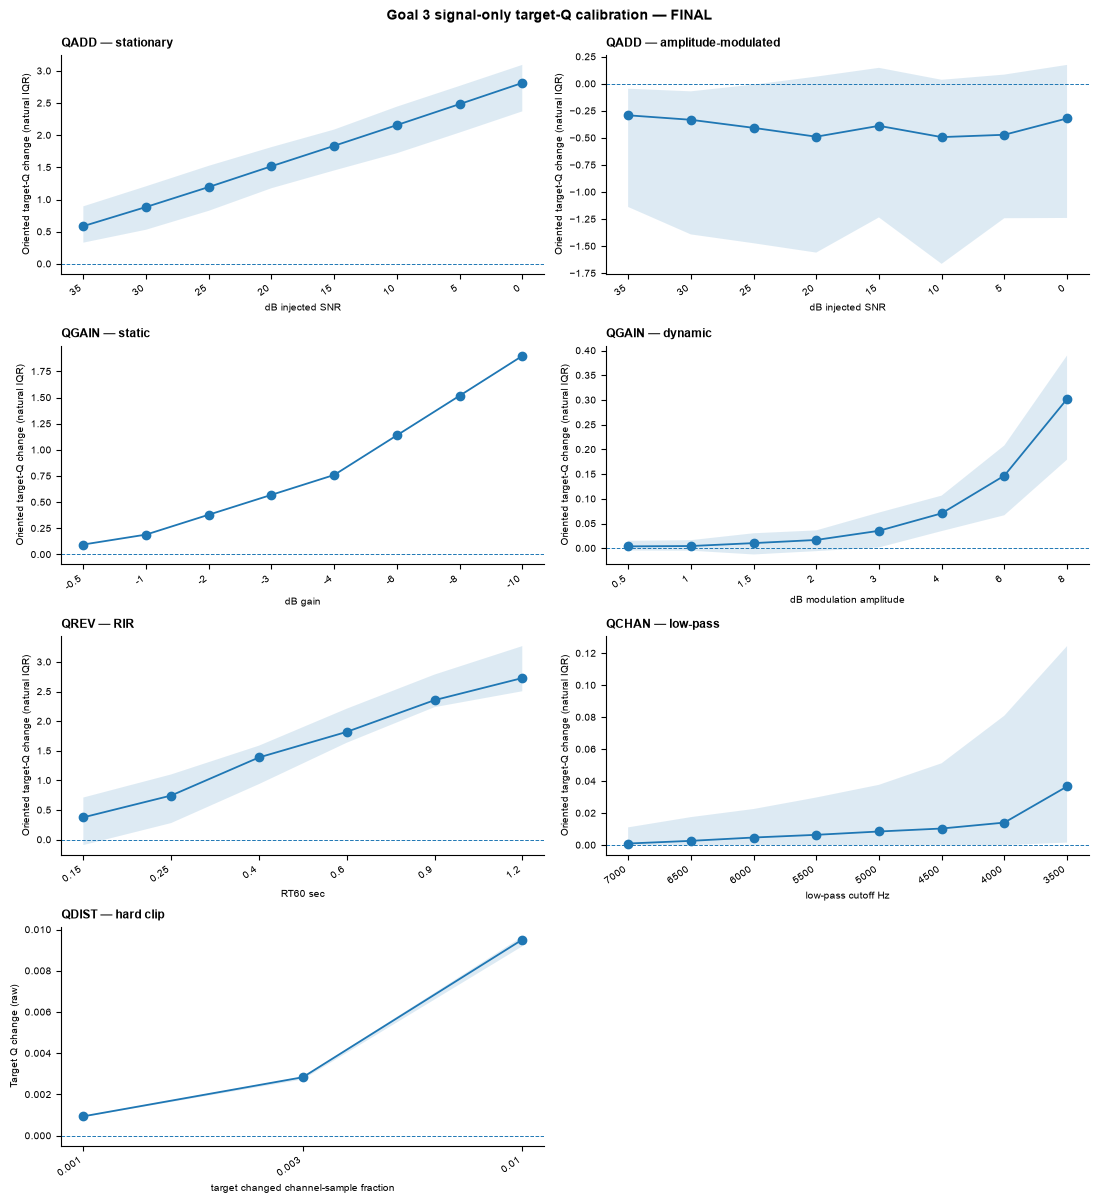

SIGNAL-ONLY CALIBRATION FIGURE: WRITTEN


In [21]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.family": ["Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
})

plot_order = [
    "stationary_colored_broadband",
    "amplitude_modulated_colored_broadband",
    "uniform_level_shift",
    "smooth_time_varying_gain",
    "RIR_convolution_RMS_matched",
    "upper_band_restriction",
    "symmetric_hard_clipping",
]

plot_labels = {
    "stationary_colored_broadband": "QADD — stationary",
    "amplitude_modulated_colored_broadband": "QADD — amplitude-modulated",
    "uniform_level_shift": "QGAIN — static",
    "smooth_time_varying_gain": "QGAIN — dynamic",
    "RIR_convolution_RMS_matched": "QREV — RIR",
    "upper_band_restriction": "QCHAN — low-pass",
    "symmetric_hard_clipping": "QDIST — hard clip",
}

fig, axes = plt.subplots(
    4,
    2,
    figsize=(11.0, 12.0),
)

axes = axes.ravel()

for index, transform in enumerate(plot_order):
    ax = axes[index]

    local = candidate_summary.loc[
        candidate_summary["transform"].eq(transform)
    ].sort_values("physical_strength_order")

    if transform == "symmetric_hard_clipping":
        y = local["oriented_target_delta_raw_median"].to_numpy(float)
        ylow = local["oriented_target_delta_raw_q25"].to_numpy(float)
        yhigh = local["oriented_target_delta_raw_q75"].to_numpy(float)
        ylabel = "Target Q change (raw)"
    else:
        y = local["target_delta_natural_iqr_median"].to_numpy(float)
        raw_q25 = local["oriented_target_delta_raw_q25"].to_numpy(float)
        raw_q75 = local["oriented_target_delta_raw_q75"].to_numpy(float)
        scale = local["natural_target_iqr_raw"].to_numpy(float)
        ylow = raw_q25 / scale
        yhigh = raw_q75 / scale
        ylabel = "Oriented target-Q change (natural IQR)"

    x = np.arange(len(local))

    ax.plot(
        x,
        y,
        marker="o",
        linewidth=1.3,
    )

    ax.fill_between(
        x,
        ylow,
        yhigh,
        alpha=0.15,
    )

    if len(selected_doses):
        selected = selected_doses.loc[
            selected_doses["transform"].eq(transform)
        ]

        selected_values = set(
            selected["candidate_value"].astype(float)
        )

        for xi, candidate_value in enumerate(
            local["candidate_value"].astype(float)
        ):
            if candidate_value in selected_values:
                ax.scatter(
                    [xi],
                    [y[xi]],
                    s=55,
                    facecolors="none",
                    linewidths=1.5,
                    zorder=5,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{value:g}" for value in local["candidate_value"]],
        rotation=35,
        ha="right",
    )

    ax.set_title(plot_labels[transform], loc="left", fontweight="bold")
    ax.set_xlabel(local["candidate_unit"].iloc[0] if len(local) else "")
    ax.set_ylabel(ylabel)
    ax.axhline(0, linewidth=0.7, linestyle="--")

axes[-1].axis("off")

fig.suptitle(
    f"Goal 3 signal-only target-Q calibration — {RUN_MODE}",
    y=0.995,
    fontsize=10,
    fontweight="bold",
)

fig.tight_layout()

for suffix, kwargs in [
    ("pdf", {}),
    ("svg", {}),
    ("png", {"dpi": 400}),
]:
    fig.savefig(
        FIGURES / f"Goal3_StageB_target_Q_calibration.{suffix}",
        bbox_inches="tight",
        **kwargs,
    )

plt.show()
plt.close(fig)

print("SIGNAL-ONLY CALIBRATION FIGURE: WRITTEN")

## 20. Freeze provenance and final Stage-B status

In [22]:
output_files = [
    path
    for path in OUT.rglob("*")
    if path.is_file()
    and not path.name.startswith(".")
]

output_hashes = {
    str(path.relative_to(OUT)): sha256_file(path)
    for path in sorted(output_files)
    if path.name not in {
        "run_manifest.json",
        "SUCCESS_STAGE_B.json",
        "NEEDS_REVISION_STAGE_B.json",
    }
}

run_manifest = {
    "created_utc": utc_now(),
    "engine_version": ENGINE_VERSION,
    "run_mode": RUN_MODE,
    "paper1_commit": PAPER1_COMMIT,
    "paper1_repository": str(PAPER1_REPO),
    "python_version": sys.version,
    "platform": platform.platform(),
    "stage_a_directory": str(STAGE_A),
    "stage_b_prep_directory": str(PREP),
    "clinical_outcomes_loaded": False,
    "clinical_predictions_loaded": False,
    "goal2_outputs_loaded": False,
    "pilot_source_count": len(pilot_run),
    "candidate_rows_per_source": len(candidate_grid),
    "qdist_fixed_doses": QDIST_FIXED_DOSES,
    "qdist_geometry": QDIST_GEOMETRY,
    "dynamic_gain_hz": DYNAMIC_GAIN_HZ,
    "selection_targets_natural_iqr": TARGET_IQR,
    "acceptance_gate_config": {
        "minimum_finite_sources_final": MIN_SELECTED_FINITE_SOURCES_FINAL,
        "minimum_expected_direction_fraction_final": (
            MIN_EXPECTED_DIRECTION_FRACTION_FINAL
        ),
        "minimum_high_dose_median_target_iqr": (
            MIN_HIGH_DOSE_MEDIAN_TARGET_IQR
        ),
    },
    "implementation_amendment": (
        "v1.1 execution uses exact pinned Paper1 transformation helpers/framework "
        "before any signal-only candidate Q response was inspected. Candidate "
        "physical grids and outcome-blind selection rule remain those frozen in "
        "Stage-B preparation."
    ),
    "all_calibration_acceptance_gates_pass": all_acceptance_pass,
    "output_hashes": output_hashes,
}

atomic_json(
    run_manifest,
    OUT / "run_manifest.json",
)

if RUN_MODE == "FINAL" and all_acceptance_pass:
    if not PERTURBATION_MANIFEST_PATH.exists():
        raise RuntimeError(
            "Acceptance passed but final perturbation manifest is missing."
        )

    success = {
        "created_utc": utc_now(),
        "status": "PASS",
        "run_mode": "FINAL",
        "engine_version": ENGINE_VERSION,
        "paper1_commit": PAPER1_COMMIT,
        "clinical_outcomes_inspected": False,
        "clinical_predictions_inspected": False,
        "dose_manifest_frozen": True,
        "dose_manifest_sha256": sha256_file(
            PERTURBATION_MANIFEST_PATH
        ),
        "next_step": (
            "Seal corrected Goal2 first-repeat fold-specific model bundles; "
            "only then run controlled clinical perturbation inference."
        ),
    }

    atomic_json(
        success,
        OUT / "SUCCESS_STAGE_B.json",
    )

    needs_revision = OUT / "NEEDS_REVISION_STAGE_B.json"
    if needs_revision.exists():
        needs_revision.unlink()

    print("\nGOAL 3 STAGE B SIGNAL-ONLY CALIBRATION: PASS")
    print("Baseline + low/medium/high doses: FROZEN")
    print("Clinical outcomes/predictions inspected: FALSE")
    print("Dose manifest:", PERTURBATION_MANIFEST_PATH)
    print(
        "NEXT: seal corrected Goal 2 first-repeat model bundles, "
        "then controlled clinical perturbation."
    )

elif RUN_MODE == "FINAL":
    revision = {
        "created_utc": utc_now(),
        "status": "NEEDS_SIGNAL_ONLY_REVISION",
        "run_mode": "FINAL",
        "engine_version": ENGINE_VERSION,
        "clinical_outcomes_inspected": False,
        "clinical_predictions_inspected": False,
        "dose_manifest_frozen": False,
        "failed_gates": acceptance.loc[
            ~acceptance["passed"].astype(bool)
        ].to_dict("records"),
        "next_step": (
            "Review only signal/Q calibration outputs; revise physical candidate "
            "grid/transform if scientifically required before any clinical "
            "model response is inspected."
        ),
    }

    atomic_json(
        revision,
        OUT / "NEEDS_REVISION_STAGE_B.json",
    )

    print("\nGOAL 3 STAGE B: SIGNAL-ONLY REVISION REQUIRED")
    print("No final dose manifest was frozen.")
    print("Clinical outcomes/predictions inspected: FALSE")

else:
    smoke_pass = bool(
        baseline["execution_status"].eq("PASS").all()
        and len(candidate_response)
        == len(pilot_run) * (1 + len(candidate_grid))
    )

    smoke_payload = {
        "created_utc": utc_now(),
        "status": "PASS" if smoke_pass else "FAIL",
        "run_mode": "SMOKE",
        "engine_version": ENGINE_VERSION,
        "paper1_commit": PAPER1_COMMIT,
        "clinical_outcomes_inspected": False,
        "clinical_predictions_inspected": False,
        "dose_manifest_frozen": False,
        "candidate_response_rows": len(candidate_response),
        "expected_candidate_response_rows": (
            len(pilot_run) * (1 + len(candidate_grid))
        ),
    }

    atomic_json(
        smoke_payload,
        OUT / "SMOKE_STATUS.json",
    )

    print(
        "\nGOAL 3 STAGE B SMOKE:",
        smoke_payload["status"],
    )

    if smoke_pass:
        print(
            "NEXT: change RUN_MODE = 'FINAL', restart kernel, and Run All."
        )
    else:
        print(
            "Do NOT start FINAL. Inspect the execution/error tables first."
        )


GOAL 3 STAGE B: SIGNAL-ONLY REVISION REQUIRED
No final dose manifest was frozen.
Clinical outcomes/predictions inspected: FALSE


In [23]:
%run -i "goal3_stageB_v1_2_targeted_revision.py"

GOAL 3 STAGE B v1.2 TARGETED REVISION
Locked from v1.1: stationary_colored_broadband, uniform_level_shift, RIR_convolution_RMS_matched, symmetric_hard_clipping
Revising only: AM-QADD structure, dynamic-QGAIN range, QCHAN range
Clinical outcomes/predictions loaded: FALSE
Final perturbation manifest will NOT be written automatically.


--- am_structure_screen ---
Pilot sources: 24
Candidate rows/source: 15
am_structure_screen: source 4/24 complete | elapsed 1.0 min
am_structure_screen: source 8/24 complete | elapsed 3.7 min
am_structure_screen: source 12/24 complete | elapsed 4.8 min
am_structure_screen: source 16/24 complete | elapsed 6.1 min
am_structure_screen: source 20/24 complete | elapsed 7.1 min
am_structure_screen: source 24/24 complete | elapsed 8.3 min

AM-QADD REVISED STRUCTURE SCREEN


,family,transform,candidate_value,candidate_unit,physical_strength_order,modulation_depth_db_pp,target_q,expected_direction_multiplier,unique_sources_total,finite_target_sources,finite_target_fraction,expected_direction_fraction,oriented_target_delta_raw_median,natural_target_iqr_raw,target_delta_natural_iqr_median,target_delta_natural_iqr_q25,target_delta_natural_iqr_q75,execution_error_fraction,screen_pass
0,QADD,amplitude_modulated_colored_broadband_v2_logdepth,10.0,dB injected SNR,-10.0,18.0,qadd_pause_level_iqr_db,1.0,24,22,0.916667,0.500000,-0.163389,8.183773,-0.019965,-0.627922,0.677194,0.0,False
1,QADD,amplitude_modulated_colored_broadband_v2_logdepth,10.0,dB injected SNR,-10.0,30.0,qadd_pause_level_iqr_db,1.0,24,23,0.958333,0.695652,6.527938,8.183773,0.797668,-0.502876,1.221994,0.0,False
2,QADD,amplitude_modulated_colored_broadband_v2_logdepth,10.0,dB injected SNR,-10.0,42.0,qadd_pause_level_iqr_db,1.0,24,23,0.958333,0.652174,9.320474,8.183773,1.138897,-0.315288,2.043958,0.0,False


RuntimeError: No revised AM-QADD modulation depth passed the outcome-blind structure screen. Stop here; do not inspect clinical outputs.

In [24]:
%run -i "goal3_stageB_v1_3_targeted_revision.py"

GOAL 3 STAGE B v1.3 TARGETED REVISION
Locked from v1.1: stationary_colored_broadband, uniform_level_shift, RIR_convolution_RMS_matched, symmetric_hard_clipping
Revising only: AM-QADD structure, dynamic-QGAIN range, QCHAN range
Clinical outcomes/predictions loaded: FALSE
Final perturbation manifest will NOT be written automatically.


--- am_structure_screen ---
Pilot sources: 24
Candidate rows/source: 15
am_structure_screen: source 4/24 complete | elapsed 2.2 min
am_structure_screen: source 8/24 complete | elapsed 6.6 min
am_structure_screen: source 12/24 complete | elapsed 8.7 min
am_structure_screen: source 16/24 complete | elapsed 11.3 min
am_structure_screen: source 20/24 complete | elapsed 13.2 min
am_structure_screen: source 24/24 complete | elapsed 15.4 min

AM-QADD REVISED STRUCTURE SCREEN


,family,transform,candidate_value,candidate_unit,physical_strength_order,modulation_depth_db_pp,target_q,expected_direction_multiplier,unique_sources_total,finite_target_sources,finite_target_fraction,expected_direction_fraction,oriented_target_delta_raw_median,natural_target_iqr_raw,target_delta_natural_iqr_median,target_delta_natural_iqr_q25,target_delta_natural_iqr_q75,execution_error_fraction,screen_pass
0,QADD,amplitude_modulated_colored_broadband_v3_inter...,10.0,dB injected SNR,-10.0,18.0,qadd_pause_level_iqr_db,1.0,24,21,0.875000,0.714286,5.142775,8.183773,0.628411,-0.115717,1.451993,0.0,True
1,QADD,amplitude_modulated_colored_broadband_v3_inter...,10.0,dB injected SNR,-10.0,24.0,qadd_pause_level_iqr_db,1.0,24,21,0.875000,0.809524,10.822941,8.183773,1.322488,0.221490,2.166133,0.0,True
2,QADD,amplitude_modulated_colored_broadband_v3_inter...,10.0,dB injected SNR,-10.0,30.0,qadd_pause_level_iqr_db,1.0,24,22,0.916667,0.909091,16.372443,8.183773,2.000598,0.861726,2.683442,0.0,True



AM-QADD v1.3 intermittent structure selected outcome-blind: 18 dB peak-to-peak
Selection rule: lowest depth meeting all frozen screen gates.

--- targeted_extension ---
Pilot sources: 24
Candidate rows/source: 71
targeted_extension: source 4/24 complete | elapsed 6.5 min
targeted_extension: source 8/24 complete | elapsed 18.7 min
targeted_extension: source 12/24 complete | elapsed 25.1 min
targeted_extension: source 16/24 complete | elapsed 33.4 min
targeted_extension: source 20/24 complete | elapsed 39.2 min
targeted_extension: source 24/24 complete | elapsed 45.6 min

TARGETED v1.3 SIGNAL EXECUTION: COMPLETE
Unique new/revised response rows: 1944

GOAL 3 STAGE B v1.3 TARGETED REVISION RESULTS

AM-QADD selected modulation structure:
  18 dB peak-to-peak | state=0.4s | jitter=±35% | transition=0.08s

Revision selection status:


,transform,selection_status
0,amplitude_modulated_colored_broadband_v3_inter...,pass
1,smooth_time_varying_gain,pass
2,upper_band_restriction,pass



Revised low / medium / high dose selection:


...


Revision acceptance gates:


,transform,gate,passed,observed,required
0,amplitude_modulated_colored_broadband_v3_inter...,three_selected_doses,True,3,3
1,amplitude_modulated_colored_broadband_v3_inter...,strict_median_monotonicity,True,"[0.5384595453548222, 0.7369753091189524, 0.853...",strictly increasing low < medium < high
2,amplitude_modulated_colored_broadband_v3_inter...,minimum_finite_pilot_sources,True,"[22.0, 21.0, 21.0]",12
3,amplitude_modulated_colored_broadband_v3_inter...,expected_direction_fraction,False,"[0.6363636363636364, 0.7142857142857143, 0.761...",0.7
4,amplitude_modulated_colored_broadband_v3_inter...,high_dose_natural_span,False,0.853561,>= 1.00 natural IQR
5,smooth_time_varying_gain,three_selected_doses,True,3,3
6,smooth_time_varying_gain,strict_median_monotonicity,True,"[0.42428519986302493, 1.0012538105163742, 2.30...",strictly increasing low < medium < high
7,smooth_time_varying_gain,minimum_finite_pilot_sources,True,"[24.0, 23.0, 23.0]",12
8,smooth_time_varying_gain,expected_direction_fraction,True,"[1.0, 0.9565217391304348, 0.9565217391304348]",0.7
9,smooth_time_varying_gain,high_dose_natural_span,True,2.305267,>= 1.00 natural IQR



High-dose off-target Q characterization:


,transform,dose_label,dose_code,target_q,q_feature,is_primary_target,natural_iqr_raw,finite_sources,median_abs_delta_raw,median_abs_delta_natural_iqr,q25_abs_delta_natural_iqr,q75_abs_delta_natural_iqr
24,amplitude_modulated_colored_broadband_v3_inter...,high,3,qadd_pause_level_iqr_db,qadd_pause_ac_level_dbfs_median,False,15.384870,21,41.782830,2.715839,2.357643,2.987234
26,amplitude_modulated_colored_broadband_v3_inter...,high,3,qadd_pause_level_iqr_db,qadd_speech_pause_level_contrast_db,False,14.248576,21,36.560264,2.565889,2.148150,2.842481
31,amplitude_modulated_colored_broadband_v3_inter...,high,3,qadd_pause_level_iqr_db,qrev_srmr_norm,False,0.737334,22,1.071032,1.452575,1.336882,2.015881
35,amplitude_modulated_colored_broadband_v3_inter...,high,3,qadd_pause_level_iqr_db,qchan_tilt_steepening_db_per_oct,False,1.483114,21,1.636481,1.103409,0.089700,1.501766
25,amplitude_modulated_colored_broadband_v3_inter...,high,3,qadd_pause_level_iqr_db,qadd_pause_level_iqr_db,True,8.183773,21,8.280366,1.011803,0.563210,1.567768
28,amplitude_modulated_colored_broadband_v3_inter...,high,3,qadd_pause_level_iqr_db,qgain_within_segment_iqr_db,False,3.142117,22,3.063849,0.975091,0.748915,1.338634
29,amplitude_modulated_colored_broadband_v3_inter...,high,3,qadd_pause_level_iqr_db,qgain_between_segment_mad_db,False,1.283636,22,1.231572,0.959440,0.485124,1.739113
27,amplitude_modulated_colored_broadband_v3_inter...,high,3,qadd_pause_level_iqr_db,qgain_typical_speech_level_dbfs,False,5.263249,22,5.008264,0.951554,0.798497,1.093774
33,amplitude_modulated_colored_broadband_v3_inter...,high,3,qadd_pause_level_iqr_db,qchan_rolloff95_deficit_hz,False,560.348101,21,486.045251,0.867399,0.000000,1.480894
32,amplitude_modulated_colored_broadband_v3_inter...,high,3,qadd_pause_level_iqr_db,qchan_ltas_distance_db,False,2.619682,21,1.297023,0.495107,0.376958,0.832361



GOAL 3 STAGE B v1.3: FURTHER SIGNAL-ONLY REVISION REQUIRED
No final perturbation manifest was written.
Clinical outcomes/predictions inspected: FALSE

Saved under:
C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\stageB_signal_only_calibration_v1_2\final


In [25]:
# ================================================================
# GOAL 3 v1.3 PROVENANCE PATH REPAIR
#
# The v1.3 script accidentally wrote its v1.3 artifacts into the
# v1.2 directory. This cell copies only v1.3 artifacts/checkpoints
# into the correct v1.3 directory. No signal computation is rerun.
# ================================================================

from pathlib import Path
import json
import shutil
import hashlib
from datetime import datetime, timezone

wrong_root = (
    ROOT
    / "outputs"
    / "goal3"
    / "stageB_signal_only_calibration_v1_2"
    / "final"
)

correct_root = (
    ROOT
    / "outputs"
    / "goal3"
    / "stageB_signal_only_calibration_v1_3"
    / "final"
)

correct_tables = correct_root / "tables"
correct_audit = correct_root / "audit"
correct_checkpoints = correct_root / "checkpoints"

for d in [
    correct_root,
    correct_tables,
    correct_audit,
    correct_checkpoints,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )


def _sha256(path):
    h = hashlib.sha256()

    with path.open("rb") as f:
        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b"",
        ):
            h.update(chunk)

    return h.hexdigest()


copied = []


# ------------------------------------------------
# v1.3-specific result tables
# ------------------------------------------------

wrong_tables = (
    wrong_root
    / "tables"
)

for src in wrong_tables.glob(
    "goal3_v13_*"
):
    dst = (
        correct_tables
        / src.name
    )

    shutil.copy2(
        src,
        dst,
    )

    copied.append({
        "source": str(src),
        "destination": str(dst),
        "sha256": _sha256(dst),
    })


# The locked-v1.1 dose table was also written
# during v1.3 and is safe to preserve here.
locked_src = (
    wrong_tables
    / "goal3_v11_locked_passing_doses.csv"
)

if locked_src.exists():
    locked_dst = (
        correct_tables
        / locked_src.name
    )

    shutil.copy2(
        locked_src,
        locked_dst,
    )

    copied.append({
        "source": str(
            locked_src
        ),
        "destination": str(
            locked_dst
        ),
        "sha256": _sha256(
            locked_dst
        ),
    })


# ------------------------------------------------
# Copy the v1.3 contract.
#
# The script incorrectly named this as a v1.2
# contract, so verify its ENGINE before copying.
# ------------------------------------------------

wrong_contract = (
    wrong_root
    / "goal3_stageB_v1_2_revision_contract.json"
)

if wrong_contract.exists():
    payload = json.loads(
        wrong_contract.read_text(
            encoding="utf-8"
        )
    )

    if payload.get(
        "engine"
    ) == V13_ENGINE:

        correct_contract = (
            correct_root
            / "goal3_stageB_v1_3_revision_contract.json"
        )

        correct_contract.write_text(
            json.dumps(
                payload,
                indent=2,
                sort_keys=True,
            ),
            encoding="utf-8",
        )

        copied.append({
            "source": str(
                wrong_contract
            ),
            "destination": str(
                correct_contract
            ),
            "sha256": _sha256(
                correct_contract
            ),
        })


# ------------------------------------------------
# Copy final v1.3 status JSON only when the
# embedded engine identifies it as v1.3.
# ------------------------------------------------

for filename in [
    "NEEDS_FURTHER_REVISION.json",
    "READY_FOR_SEAL.json",
]:
    src = (
        wrong_root
        / filename
    )

    if not src.exists():
        continue

    try:
        payload = json.loads(
            src.read_text(
                encoding="utf-8"
            )
        )
    except Exception:
        continue

    if payload.get(
        "engine"
    ) != V13_ENGINE:
        continue

    dst = (
        correct_root
        / filename
    )

    shutil.copy2(
        src,
        dst,
    )

    copied.append({
        "source": str(src),
        "destination": str(dst),
        "sha256": _sha256(dst),
    })


# ------------------------------------------------
# Copy ONLY checkpoint files whose embedded
# engine says they belong to v1.3.
# ------------------------------------------------

wrong_checkpoints = (
    wrong_root
    / "checkpoints"
)

checkpoint_count = 0

if wrong_checkpoints.exists():

    for src in wrong_checkpoints.rglob(
        "*.json"
    ):

        try:
            payload = json.loads(
                src.read_text(
                    encoding="utf-8"
                )
            )
        except Exception:
            continue

        if payload.get(
            "engine"
        ) != V13_ENGINE:
            continue

        relative = (
            src.relative_to(
                wrong_checkpoints
            )
        )

        dst = (
            correct_checkpoints
            / relative
        )

        dst.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        shutil.copy2(
            src,
            dst,
        )

        checkpoint_count += 1


# ------------------------------------------------
# Write repair manifest
# ------------------------------------------------

repair_manifest = {
    "created_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "reason": (
        "Goal 3 Stage-B v1.3 execution "
        "used an incorrect v1.2 output-root "
        "literal. Numerical v1.3 results were "
        "preserved and copied without "
        "recomputation."
    ),
    "engine": V13_ENGINE,
    "source_directory": str(
        wrong_root
    ),
    "correct_directory": str(
        correct_root
    ),
    "copied_result_files": copied,
    "v13_checkpoints_copied": (
        checkpoint_count
    ),
    "waveform_recomputation": False,
}

repair_path = (
    correct_root
    / "V13_PROVENANCE_PATH_REPAIR.json"
)

repair_path.write_text(
    json.dumps(
        repair_manifest,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)


# Update current-kernel paths so subsequent cells
# point to the corrected directory.

V13_OUT = correct_root
V13_TABLES = correct_tables
V13_AUDIT = correct_audit
V13_CHECKPOINTS = (
    correct_checkpoints
)


print(
    "GOAL 3 v1.3 PROVENANCE REPAIR: PASS"
)

print(
    "Correct root:",
    V13_OUT,
)

print(
    "v1.3 result files copied:",
    len(copied),
)

print(
    "v1.3 checkpoints copied:",
    checkpoint_count,
)

print(
    "No waveform computation was rerun."
)

GOAL 3 v1.3 PROVENANCE REPAIR: PASS
Correct root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\stageB_signal_only_calibration_v1_3\final
v1.3 result files copied: 13
v1.3 checkpoints copied: 1944
No waveform computation was rerun.


In [26]:
# ================================================================
# AM-QADD SIGNAL-ONLY DISPOSITION
#
# This is a PRE-CLINICAL-RESPONSE design amendment.
# No diagnosis, bulbar score, prediction, or model error has been
# inspected for this perturbation.
# ================================================================

am_transform = (
    "amplitude_modulated_"
    "colored_broadband_v3_intermittent"
)

am_failed = (
    revision_acceptance.loc[
        revision_acceptance[
            "transform"
        ].eq(am_transform)
        & ~revision_acceptance[
            "passed"
        ].astype(bool)
    ]
    .copy()
)

am_disposition = {
    "created_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),

    "status": (
        "DROPPED_FROM_PRIMARY_CONTROLLED_"
        "PERTURBATION_GRID_BEFORE_"
        "CLINICAL_MODEL_UNBLINDING"
    ),

    "family": "QADD",

    "transform": am_transform,

    "clinical_outcomes_inspected": False,

    "clinical_predictions_inspected": False,

    "clinical_errors_inspected": False,

    "reason": (
        "After multiple outcome-blind "
        "signal-only calibration attempts, "
        "the amplitude-modulated QADD "
        "sub-transform did not satisfy the "
        "prespecified final target-Q "
        "acceptance gates consistently."
    ),

    "failed_v13_gates": (
        am_failed[
            [
                "gate",
                "observed",
                "required",
            ]
        ].to_dict(
            "records"
        )
    ),

    "retained_QADD_primary_transform": (
        "stationary_colored_broadband"
    ),

    "interpretation": (
        "The failed calibration is retained "
        "as an engineering/signal-only "
        "negative result. It is not used for "
        "clinical perturbation inference."
    ),
}

am_path = (
    V13_AUDIT
    / "AM_QADD_SIGNAL_ONLY_DISPOSITION.json"
)

am_path.write_text(
    json.dumps(
        am_disposition,
        indent=2,
        sort_keys=True,
        default=str,
    ),
    encoding="utf-8",
)

print(
    "AM-QADD PRIMARY CONTROLLED SUBTYPE: DROPPED"
)

print(
    "Stationary QADD remains retained."
)

print(
    "Clinical model response inspected: FALSE"
)

AM-QADD PRIMARY CONTROLLED SUBTYPE: DROPPED
Stationary QADD remains retained.
Clinical model response inspected: FALSE


In [27]:
# ================================================================
# QCHAN SIGNAL-ONLY DUAL-VERIFICATION AUDIT
#
# No new waveforms are generated.
# No clinical data are accessed.
#
# We examine both QCHAN verification quantities already frozen
# in Stage A:
#
#   primary   = rolloff95 deficit
#   secondary = high-band-ratio deficit
# ================================================================

qchan_transform = (
    "upper_band_restriction"
)


# Existing v1.1 QCHAN candidates:
qchan_old_delta = (
    v11_delta.loc[
        v11_delta[
            "transform"
        ].eq(
            qchan_transform
        )
    ]
    .copy()
)


# New v1.3 QCHAN candidates:
qchan_new_delta = (
    v13_delta.loc[
        v13_delta[
            "transform"
        ].eq(
            qchan_transform
        )
    ]
    .copy()
)


# Combine all signal-only QCHAN candidates.
qchan_all_delta = (
    pd.concat(
        [
            qchan_old_delta,
            qchan_new_delta,
        ],
        ignore_index=True,
        sort=False,
    )
    .drop_duplicates(
        [
            "logical_recording_id",
            "candidate_value",
            "exemplar",
        ],
        keep="last",
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------
# Primary frozen QCHAN verification:
# rolloff95 deficit
# ------------------------------------------------

qchan_rolloff_summary = (
    v13_target_summary(
        qchan_all_delta,
        target_q=(
            "qchan_rolloff95_deficit_hz"
        ),
        direction=+1.0,
    )
)


# ------------------------------------------------
# Prespecified secondary QCHAN verification:
# high-band-ratio deficit
# ------------------------------------------------

qchan_highband_summary = (
    v13_target_summary(
        qchan_all_delta,
        target_q=(
            "qchan_highband_ratio_deficit"
        ),
        direction=+1.0,
    )
)


print(
    "\nQCHAN PRIMARY VERIFICATION:"
    " ROLLOFF95 DEFICIT"
)

display(
    qchan_rolloff_summary[
        [
            "candidate_value",
            "candidate_unit",
            "finite_target_sources",
            "expected_direction_fraction",
            "target_delta_natural_iqr_median",
            "target_delta_natural_iqr_q25",
            "target_delta_natural_iqr_q75",
        ]
    ]
)


print(
    "\nQCHAN PRESPECIFIED SECONDARY VERIFICATION:"
    " HIGH-BAND-RATIO DEFICIT"
)

display(
    qchan_highband_summary[
        [
            "candidate_value",
            "candidate_unit",
            "finite_target_sources",
            "expected_direction_fraction",
            "target_delta_natural_iqr_median",
            "target_delta_natural_iqr_q25",
            "target_delta_natural_iqr_q75",
        ]
    ]
)


# ------------------------------------------------
# Ask the unchanged 0.5 / 1 / 2-IQR selector what
# it would choose using the prespecified secondary
# QCHAN verification variable.
#
# THIS DOES NOT FREEZE OR ACCEPT ANYTHING.
# ------------------------------------------------

(
    qchan_secondary_selected,
    qchan_secondary_status,
) = v13_select_three(
    qchan_highband_summary
)


print()
print(
    "Secondary-target selection status:",
    qchan_secondary_status,
)


if qchan_secondary_selected is not None:

    display(
        qchan_secondary_selected[
            [
                "candidate_value",
                "candidate_unit",
                "dose_label",
                "target_delta_natural_iqr_median",
                "finite_target_sources",
                "expected_direction_fraction",
            ]
        ]
    )


    secondary_response = (
        qchan_secondary_selected[
            "target_delta_natural_iqr_median"
        ].to_numpy(
            float
        )
    )

    secondary_direction = (
        qchan_secondary_selected[
            "expected_direction_fraction"
        ].to_numpy(
            float
        )
    )

    secondary_finite = (
        qchan_secondary_selected[
            "finite_target_sources"
        ].to_numpy(
            float
        )
    )


    qchan_secondary_gate = {
        "three_doses": (
            len(
                qchan_secondary_selected
            )
            == 3
        ),

        "strict_monotonicity": (
            np.all(
                np.diff(
                    secondary_response
                )
                > 0
            )
        ),

        "finite_sources": (
            np.all(
                secondary_finite
                >= 12
            )
        ),

        "direction_fraction": (
            np.all(
                secondary_direction
                >= 0.70
            )
        ),

        "high_span_ge_1_IQR": (
            secondary_response[
                -1
            ]
            >= 1.0
        ),
    }


    print()
    print(
        "QCHAN secondary verification gates:"
    )

    for key, value in (
        qchan_secondary_gate.items()
    ):
        print(
            f"  {key}: {value}"
        )


    print()

    if all(
        qchan_secondary_gate.values()
    ):
        print(
            "QCHAN SECONDARY VERIFICATION:"
            " TECHNICALLY ADEQUATE"
        )
        print(
            "Do NOT seal yet. "
            "A documented signal-only "
            "design amendment is required."
        )

    else:
        print(
            "QCHAN SECONDARY VERIFICATION:"
            " ALSO INADEQUATE"
        )
        print(
            "Do not further intensify the "
            "filter automatically."
        )

else:

    print(
        "No valid low/medium/high solution "
        "exists using the prespecified "
        "secondary QCHAN verification target."
    )


QCHAN PRIMARY VERIFICATION: ROLLOFF95 DEFICIT


,candidate_value,candidate_unit,finite_target_sources,expected_direction_fraction,target_delta_natural_iqr_median,target_delta_natural_iqr_q25,target_delta_natural_iqr_q75
0,7000.0,low-pass cutoff Hz,24,0.625000,0.000971,0.000000,0.011076
1,6500.0,low-pass cutoff Hz,24,0.625000,0.002647,0.000000,0.017488
2,6000.0,low-pass cutoff Hz,24,0.625000,0.004729,0.000000,0.022557
3,5500.0,low-pass cutoff Hz,24,0.625000,0.006414,0.000000,0.029754
4,5000.0,low-pass cutoff Hz,24,0.625000,0.008494,0.000000,0.037689
5,4500.0,low-pass cutoff Hz,24,0.625000,0.010358,0.000000,0.051177
6,4000.0,low-pass cutoff Hz,23,0.652174,0.014065,0.000000,0.080923
7,3500.0,low-pass cutoff Hz,23,0.739130,0.036665,0.001551,0.124450
8,3250.0,low-pass cutoff Hz,23,0.782609,0.037545,0.003720,0.134872
9,3000.0,low-pass cutoff Hz,23,0.913043,0.042773,0.014985,0.142782



QCHAN PRESPECIFIED SECONDARY VERIFICATION: HIGH-BAND-RATIO DEFICIT


,candidate_value,candidate_unit,finite_target_sources,expected_direction_fraction,target_delta_natural_iqr_median,target_delta_natural_iqr_q25,target_delta_natural_iqr_q75
0,7000.0,low-pass cutoff Hz,24,0.625000,0.026644,0.000000,0.116238
1,6500.0,low-pass cutoff Hz,24,0.625000,0.061442,0.000000,0.201045
2,6000.0,low-pass cutoff Hz,24,0.708333,0.102679,0.000000,0.317962
3,5500.0,low-pass cutoff Hz,24,0.708333,0.209385,0.000000,0.372093
4,5000.0,low-pass cutoff Hz,24,0.791667,0.262676,0.003992,0.518067
5,4500.0,low-pass cutoff Hz,24,0.875000,0.371841,0.046512,0.813926
6,4000.0,low-pass cutoff Hz,23,0.869565,0.661526,0.367250,0.990645
7,3500.0,low-pass cutoff Hz,23,0.956522,0.937980,0.457042,1.314208
8,3250.0,low-pass cutoff Hz,23,1.000000,1.164715,0.839627,1.569306
9,3000.0,low-pass cutoff Hz,23,1.000000,1.569456,0.944811,1.731295



Secondary-target selection status: pass


,candidate_value,candidate_unit,dose_label,target_delta_natural_iqr_median,finite_target_sources,expected_direction_fraction
5,4500.0,low-pass cutoff Hz,low,0.371841,24,0.875000
7,3500.0,low-pass cutoff Hz,medium,0.937980,23,0.956522
13,2000.0,low-pass cutoff Hz,high,1.678397,23,1.000000



QCHAN secondary verification gates:
  three_doses: True
  strict_monotonicity: True
  finite_sources: True
  direction_fraction: True
  high_span_ge_1_IQR: True

QCHAN SECONDARY VERIFICATION: TECHNICALLY ADEQUATE
Do NOT seal yet. A documented signal-only design amendment is required.


In [28]:
# ================================================================
# GOAL 3 STAGE B — QCHAN SIGNAL-ONLY DESIGN AMENDMENT
#
# This amendment is made BEFORE any diagnosis/severity model
# response to controlled perturbations is inspected.
#
# QCHAN remains an upper-band-restriction intervention.
#
# Original primary verification:
#   qchan_rolloff95_deficit_hz
#
# Prespecified secondary verification:
#   qchan_highband_ratio_deficit
#
# The primary verification was directional but did not achieve
# the prespecified >=1 natural-IQR high-dose span.
#
# The prespecified secondary verification satisfied all
# low/medium/high calibration gates.
# ================================================================

from datetime import datetime, timezone
import json
import numpy as np
import pandas as pd


# ------------------------------------------------
# Hard gate: QCHAN secondary verification must
# have passed every calibration criterion.
# ------------------------------------------------

if qchan_secondary_selected is None:
    raise RuntimeError(
        "QCHAN secondary-target dose selection is missing."
    )

if len(qchan_secondary_selected) != 3:
    raise RuntimeError(
        "QCHAN secondary verification did not select exactly "
        "three doses."
    )

secondary_response = (
    qchan_secondary_selected[
        "target_delta_natural_iqr_median"
    ]
    .to_numpy(float)
)

secondary_direction = (
    qchan_secondary_selected[
        "expected_direction_fraction"
    ]
    .to_numpy(float)
)

secondary_finite = (
    qchan_secondary_selected[
        "finite_target_sources"
    ]
    .to_numpy(float)
)


qchan_amendment_gates = {
    "three_selected_doses": (
        len(qchan_secondary_selected) == 3
    ),

    "strict_median_monotonicity": bool(
        np.isfinite(
            secondary_response
        ).all()
        and np.all(
            np.diff(
                secondary_response
            ) > 0
        )
    ),

    "minimum_finite_pilot_sources": bool(
        np.all(
            secondary_finite >= 12
        )
    ),

    "expected_direction_fraction": bool(
        np.all(
            secondary_direction >= 0.70
        )
    ),

    "high_dose_natural_span": bool(
        np.isfinite(
            secondary_response[-1]
        )
        and secondary_response[-1]
        >= 1.0
    ),
}


if not all(
    qchan_amendment_gates.values()
):
    raise RuntimeError(
        "QCHAN secondary verification does not satisfy "
        "all frozen acceptance gates."
    )


# ------------------------------------------------
# Original rolloff-95 result retained explicitly.
# ------------------------------------------------

qchan_rolloff_v13 = (
    revision_selected.loc[
        revision_selected[
            "transform"
        ].eq(
            "upper_band_restriction"
        )
    ]
    .sort_values(
        "dose_code"
    )
    .copy()
)

if len(qchan_rolloff_v13) != 3:
    raise RuntimeError(
        "Expected exactly three v1.3 QCHAN rolloff-selected "
        "rows for amendment provenance."
    )


qchan_amendment = {
    "created_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),

    "status": (
        "APPROVED_SIGNAL_ONLY_PRE_CLINICAL_AMENDMENT"
    ),

    "family": "QCHAN",

    "transform": (
        "upper_band_restriction"
    ),

    "clinical_outcomes_inspected": False,

    "clinical_predictions_inspected": False,

    "clinical_errors_inspected": False,

    "original_primary_verification_feature": (
        "qchan_rolloff95_deficit_hz"
    ),

    "prespecified_secondary_verification_feature": (
        "qchan_highband_ratio_deficit"
    ),

    "reason": (
        "Upper-band restriction produced a consistent "
        "directional response in rolloff95 deficit, but "
        "the strongest calibrated candidate did not span "
        "the prespecified >=1 natural-IQR threshold. "
        "The independently prespecified secondary QCHAN "
        "verification measure, high-band-ratio deficit, "
        "satisfied all dose-separation gates. The "
        "intervention is therefore retained as a "
        "multidimensional upper-band-restriction "
        "perturbation, with dose calibration anchored to "
        "the prespecified high-band-ratio verification "
        "measure."
    ),

    "interpretation_constraint": (
        "The controlled QCHAN intervention must not be "
        "described as an isolated manipulation of "
        "rolloff95. It is a multidimensional upper-band "
        "restriction that changes several channel-related "
        "spectral descriptors."
    ),

    "primary_rolloff_selected_response": (
        qchan_rolloff_v13[
            [
                "candidate_value",
                "candidate_unit",
                "dose_label",
                "target_delta_natural_iqr_median",
                "finite_target_sources",
                "expected_direction_fraction",
            ]
        ].to_dict(
            "records"
        )
    ),

    "secondary_selected_response": (
        qchan_secondary_selected[
            [
                "candidate_value",
                "candidate_unit",
                "dose_label",
                "target_delta_natural_iqr_median",
                "finite_target_sources",
                "expected_direction_fraction",
            ]
        ].to_dict(
            "records"
        )
    ),

    "secondary_acceptance_gates": (
        qchan_amendment_gates
    ),

    "further_signal_only_tuning_allowed": False,
}


qchan_amendment_path = (
    V13_AUDIT
    / "QCHAN_SIGNAL_ONLY_DESIGN_AMENDMENT.json"
)

qchan_amendment_path.write_text(
    json.dumps(
        qchan_amendment,
        indent=2,
        sort_keys=True,
        default=str,
    ),
    encoding="utf-8",
)


print(
    "QCHAN SIGNAL-ONLY DESIGN AMENDMENT: PASS"
)

print(
    "Dose anchor:",
    "qchan_highband_ratio_deficit",
)

print(
    "Clinical model response inspected: FALSE"
)

print(
    "Further QCHAN calibration permitted: FALSE"
)

QCHAN SIGNAL-ONLY DESIGN AMENDMENT: PASS
Dose anchor: qchan_highband_ratio_deficit
Clinical model response inspected: FALSE
Further QCHAN calibration permitted: FALSE


In [29]:
# ================================================================
# GOAL 3 STAGE B — ASSEMBLE FINAL SIGNAL-ONLY DOSE MANIFEST
# ================================================================

# ------------------------------------------------
# 1. Four transforms already locked from v1.1
# ------------------------------------------------

final_locked_v11 = (
    locked_selected.loc[
        locked_selected[
            "transform"
        ].isin(
            [
                "stationary_colored_broadband",
                "uniform_level_shift",
                "RIR_convolution_RMS_matched",
                "symmetric_hard_clipping",
            ]
        )
    ]
    .copy()
)

if len(final_locked_v11) != 12:
    raise RuntimeError(
        "Expected 12 selected rows from the four "
        "locked v1.1 transforms."
    )


# ------------------------------------------------
# 2. Dynamic QGAIN from successful v1.3 extension
# ------------------------------------------------

final_dynamic_gain = (
    revision_selected.loc[
        revision_selected[
            "transform"
        ].eq(
            "smooth_time_varying_gain"
        )
    ]
    .copy()
)

if len(final_dynamic_gain) != 3:
    raise RuntimeError(
        "Expected three selected dynamic-QGAIN doses."
    )


# ------------------------------------------------
# 3. QCHAN using the approved prespecified
#    secondary verification anchor.
# ------------------------------------------------

final_qchan = (
    qchan_secondary_selected.copy()
)

if len(final_qchan) != 3:
    raise RuntimeError(
        "Expected three selected QCHAN doses."
    )


# Preserve canonical transform identity.
final_qchan[
    "transform"
] = "upper_band_restriction"

final_qchan[
    "family"
] = "QCHAN"


# ------------------------------------------------
# Add provenance / interpretation columns
# ------------------------------------------------

final_locked_v11[
    "calibration_source"
] = "StageB_v1.1_signal_only"

final_dynamic_gain[
    "calibration_source"
] = "StageB_v1.3_signal_only"

final_qchan[
    "calibration_source"
] = (
    "StageB_v1.3_signal_only_"
    "QCHAN_prespecified_secondary_verification"
)


final_locked_v11[
    "dose_anchor_role"
] = "prespecified_primary"

final_dynamic_gain[
    "dose_anchor_role"
] = "prespecified_primary"

final_qchan[
    "dose_anchor_role"
] = "prespecified_secondary"


final_locked_v11[
    "design_amendment"
] = False

final_dynamic_gain[
    "design_amendment"
] = False

final_qchan[
    "design_amendment"
] = True


final_locked_v11[
    "multidimensional_intervention"
] = False

final_dynamic_gain[
    "multidimensional_intervention"
] = True

final_qchan[
    "multidimensional_intervention"
] = True


# QREV also showed meaningful off-target Q movement,
# so mark it transparently as multidimensional.
final_locked_v11.loc[
    final_locked_v11[
        "transform"
    ].eq(
        "RIR_convolution_RMS_matched"
    ),
    "multidimensional_intervention",
] = True


# ------------------------------------------------
# Combine all six perturbation structures
# ------------------------------------------------

goal3_final_manifest = pd.concat(
    [
        final_locked_v11,
        final_dynamic_gain,
        final_qchan,
    ],
    ignore_index=True,
    sort=False,
)


# ------------------------------------------------
# Hard structural gates
# ------------------------------------------------

EXPECTED_TRANSFORMS = {
    "stationary_colored_broadband",
    "uniform_level_shift",
    "smooth_time_varying_gain",
    "RIR_convolution_RMS_matched",
    "upper_band_restriction",
    "symmetric_hard_clipping",
}


actual_transforms = set(
    goal3_final_manifest[
        "transform"
    ].astype(str)
)


if actual_transforms != EXPECTED_TRANSFORMS:
    raise RuntimeError(
        "Final perturbation transform set mismatch.\n"
        f"Expected: {sorted(EXPECTED_TRANSFORMS)}\n"
        f"Observed: {sorted(actual_transforms)}"
    )


if len(
    goal3_final_manifest
) != 18:
    raise RuntimeError(
        "Expected exactly 18 perturbation-dose rows "
        "(6 transforms × 3 doses)."
    )


dose_counts = (
    goal3_final_manifest
    .groupby(
        "transform"
    )[
        "dose_label"
    ]
    .nunique()
)

if not dose_counts.eq(3).all():
    raise RuntimeError(
        "Each perturbation transform must have exactly "
        "three dose labels."
    )


expected_dose_labels = {
    "low",
    "medium",
    "high",
}

for transform, local in (
    goal3_final_manifest.groupby(
        "transform"
    )
):
    labels = set(
        local[
            "dose_label"
        ].astype(str)
    )

    if labels != expected_dose_labels:
        raise RuntimeError(
            f"{transform}: invalid dose labels {labels}"
        )


if goal3_final_manifest[
    [
        "transform",
        "dose_label",
    ]
].duplicated().any():

    raise RuntimeError(
        "Duplicate transform × dose rows in final manifest."
    )


# ------------------------------------------------
# AM-QADD must be absent.
# ------------------------------------------------

if goal3_final_manifest[
    "transform"
].astype(str).str.contains(
    "amplitude_modulated",
    regex=False,
).any():

    raise RuntimeError(
        "Dropped AM-QADD subtype unexpectedly entered "
        "the final perturbation manifest."
    )


# ------------------------------------------------
# No clinical fields may be present.
# ------------------------------------------------

prohibited_clinical_fields = {
    "diagnosis",
    "y",
    "bulbar_score",
    "ALSFRS",
    "age_at_recording_years",
    "prediction",
    "loss",
    "absolute_error",
    "brier",
}

leaked_fields = (
    prohibited_clinical_fields
    & set(
        goal3_final_manifest.columns
    )
)

if leaked_fields:
    raise RuntimeError(
        "Clinical fields unexpectedly present in "
        f"perturbation manifest: {sorted(leaked_fields)}"
    )


# ------------------------------------------------
# Add final governance metadata.
# ------------------------------------------------

goal3_final_manifest[
    "signal_only_calibration"
] = True

goal3_final_manifest[
    "clinical_response_used_for_selection"
] = False

goal3_final_manifest[
    "further_dose_tuning_allowed"
] = False


goal3_final_manifest = (
    goal3_final_manifest.sort_values(
        [
            "family",
            "transform",
            "dose_code",
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    goal3_final_manifest[
        [
            "family",
            "transform",
            "dose_label",
            "candidate_value",
            "candidate_unit",
            "target_q",
            "target_delta_natural_iqr_median",
            "finite_target_sources",
            "expected_direction_fraction",
            "dose_anchor_role",
            "design_amendment",
            "multidimensional_intervention",
        ]
    ]
)


print()
print(
    "FINAL GOAL 3 PERTURBATION GRID STRUCTURE: PASS"
)

print(
    "Transforms:",
    goal3_final_manifest[
        "transform"
    ].nunique()
)

print(
    "Dose rows:",
    len(
        goal3_final_manifest
    )
)

print(
    "AM-QADD included:",
    False
)

print(
    "Clinical response used for selection:",
    False
)

,family,transform,dose_label,candidate_value,candidate_unit,target_q,target_delta_natural_iqr_median,finite_target_sources,expected_direction_fraction,dose_anchor_role,design_amendment,multidimensional_intervention
0,QADD,stationary_colored_broadband,low,35.000,dB injected SNR,qadd_pause_ac_level_dbfs_median,0.586629,23,0.956522,prespecified_primary,False,False
1,QADD,stationary_colored_broadband,medium,30.000,dB injected SNR,qadd_pause_ac_level_dbfs_median,0.883983,23,1.000000,prespecified_primary,False,False
2,QADD,stationary_colored_broadband,high,10.000,dB injected SNR,qadd_pause_ac_level_dbfs_median,2.157530,22,1.000000,prespecified_primary,False,False
3,QCHAN,upper_band_restriction,low,4500.000,low-pass cutoff Hz,qchan_highband_ratio_deficit,0.371841,24,0.875000,prespecified_secondary,True,True
4,QCHAN,upper_band_restriction,medium,3500.000,low-pass cutoff Hz,qchan_highband_ratio_deficit,0.937980,23,0.956522,prespecified_secondary,True,True
5,QCHAN,upper_band_restriction,high,2000.000,low-pass cutoff Hz,qchan_highband_ratio_deficit,1.678397,23,1.000000,prespecified_secondary,True,True
6,QDIST,symmetric_hard_clipping,low,0.001,target changed channel-sample fraction,qdist_hard_clipped_sample_fraction,NaN,24,1.000000,prespecified_primary,False,False
7,QDIST,symmetric_hard_clipping,medium,0.003,target changed channel-sample fraction,qdist_hard_clipped_sample_fraction,NaN,24,1.000000,prespecified_primary,False,False
8,QDIST,symmetric_hard_clipping,high,0.010,target changed channel-sample fraction,qdist_hard_clipped_sample_fraction,NaN,24,1.000000,prespecified_primary,False,False
9,QGAIN,smooth_time_varying_gain,low,10.000,dB modulation amplitude,qgain_within_segment_iqr_db,0.424285,24,1.000000,prespecified_primary,False,True



FINAL GOAL 3 PERTURBATION GRID STRUCTURE: PASS
Transforms: 6
Dose rows: 18
AM-QADD included: False
Clinical response used for selection: False


In [30]:
# ================================================================
# GOAL 3 STAGE B — FINAL IMMUTABLE SIGNAL-ONLY SEAL
# ================================================================

import hashlib
import json
from datetime import datetime, timezone


def goal3_sha256(path):
    h = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b"",
        ):
            h.update(chunk)

    return h.hexdigest()


FINAL_MANIFEST_PATH = (
    V13_TABLES
    / "goal3_perturbation_manifest.csv"
)


# ------------------------------------------------
# Refuse accidental overwrite of a different seal.
# ------------------------------------------------

if FINAL_MANIFEST_PATH.exists():

    existing = pd.read_csv(
        FINAL_MANIFEST_PATH
    )

    existing_normalized = (
        existing.fillna("")
        .astype(str)
    )

    proposed_normalized = (
        goal3_final_manifest.fillna("")
        .astype(str)
    )

    if (
        list(
            existing_normalized.columns
        )
        != list(
            proposed_normalized.columns
        )
        or not existing_normalized.equals(
            proposed_normalized
        )
    ):
        raise RuntimeError(
            "A different Goal 3 perturbation manifest "
            "already exists. Refusing overwrite."
        )

else:

    goal3_final_manifest.to_csv(
        FINAL_MANIFEST_PATH,
        index=False,
    )


manifest_hash = goal3_sha256(
    FINAL_MANIFEST_PATH
)


am_disposition_path = (
    V13_AUDIT
    / "AM_QADD_SIGNAL_ONLY_DISPOSITION.json"
)

qchan_amendment_path = (
    V13_AUDIT
    / "QCHAN_SIGNAL_ONLY_DESIGN_AMENDMENT.json"
)


for required_path in [
    am_disposition_path,
    qchan_amendment_path,
]:

    if not required_path.exists():
        raise FileNotFoundError(
            required_path
        )


seal = {
    "created_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),

    "status": (
        "GOAL3_STAGE_B_SIGNAL_ONLY_SEALED"
    ),

    "perturbation_manifest": str(
        FINAL_MANIFEST_PATH
    ),

    "perturbation_manifest_sha256": (
        manifest_hash
    ),

    "n_perturbation_structures": 6,

    "n_nonbaseline_dose_rows": 18,

    "dose_labels": [
        "low",
        "medium",
        "high",
    ],

    "baseline_definition": (
        "unmodified deterministic held-out source "
        "processed through the same complete pipeline"
    ),

    "retained_transforms": sorted(
        EXPECTED_TRANSFORMS
    ),

    "dropped_transforms": [
        (
            "amplitude_modulated_"
            "colored_broadband_v3_intermittent"
        )
    ],

    "am_qadd_disposition_sha256": (
        goal3_sha256(
            am_disposition_path
        )
    ),

    "qchan_design_amendment_sha256": (
        goal3_sha256(
            qchan_amendment_path
        )
    ),

    "qchan_dose_anchor": (
        "qchan_highband_ratio_deficit"
    ),

    "qchan_interpretation": (
        "multidimensional upper-band restriction; "
        "not isolated rolloff95 manipulation"
    ),

    "clinical_outcomes_inspected_for_dose_selection": (
        False
    ),

    "clinical_predictions_inspected_for_dose_selection": (
        False
    ),

    "clinical_errors_inspected_for_dose_selection": (
        False
    ),

    "further_perturbation_tuning_allowed": (
        False
    ),

    "paper1_commit": PAPER1_COMMIT,

    "next_allowed_stage": (
        "controlled held-out perturbation experiment "
        "using frozen Goal 2 model bundles"
    ),
}


SEAL_PATH = (
    V13_OUT
    / "GOAL3_STAGE_B_SIGNAL_ONLY_SEAL.json"
)

SEAL_PATH.write_text(
    json.dumps(
        seal,
        indent=2,
        sort_keys=True,
        default=str,
    ),
    encoding="utf-8",
)


SUCCESS_PATH = (
    V13_OUT
    / "SUCCESS"
)

SUCCESS_PATH.write_text(
    (
        "GOAL 3 STAGE B SIGNAL-ONLY CALIBRATION SEALED\n"
        f"manifest_sha256={manifest_hash}\n"
        "clinical_model_response_used_for_selection=FALSE\n"
        "further_dose_tuning_allowed=FALSE\n"
    ),
    encoding="utf-8",
)


# ------------------------------------------------
# Re-read and validate sealed artifact.
# ------------------------------------------------

sealed_manifest = pd.read_csv(
    FINAL_MANIFEST_PATH
)


if len(
    sealed_manifest
) != 18:
    raise RuntimeError(
        "Post-write perturbation manifest row-count failure."
    )


if (
    sealed_manifest[
        "transform"
    ].nunique()
    != 6
):
    raise RuntimeError(
        "Post-write transform-count failure."
    )


if goal3_sha256(
    FINAL_MANIFEST_PATH
) != manifest_hash:

    raise RuntimeError(
        "Post-write manifest hash mismatch."
    )


print(
    "=" * 72
)

print(
    "GOAL 3 STAGE B SIGNAL-ONLY CALIBRATION: SEALED"
)

print(
    "=" * 72
)

print(
    "Perturbation structures: 6"
)

print(
    "Dose rows: 18"
)

print(
    "AM-QADD: DROPPED"
)

print(
    "QCHAN: RETAINED AS MULTIDIMENSIONAL"
)

print(
    "Clinical response used for calibration: FALSE"
)

print(
    "Further perturbation tuning allowed: FALSE"
)

print(
    "Manifest SHA-256:",
    manifest_hash
)

print()

print(
    "NEXT ALLOWED STEP:"
)

print(
    "Freeze/reproduce Goal 2 model bundles, "
    "then begin controlled Goal 3 perturbation inference."
)

GOAL 3 STAGE B SIGNAL-ONLY CALIBRATION: SEALED
Perturbation structures: 6
Dose rows: 18
AM-QADD: DROPPED
QCHAN: RETAINED AS MULTIDIMENSIONAL
Clinical response used for calibration: FALSE
Further perturbation tuning allowed: FALSE
Manifest SHA-256: c553dd58d978d3f5658c1c49a33595049f2a418c82c4e8af6c50d83aaba6c0e6

NEXT ALLOWED STEP:
Freeze/reproduce Goal 2 model bundles, then begin controlled Goal 3 perturbation inference.
